# **MAE**

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

***PARAMETERS***

In [ ]:
#setting the seed
SEED = 42
keras.utils.set_random_seed(SEED)

#hyperparameters
BUFFER_SIZE = 1224 # how many imgs are we shuffling at once
BATCH_SIZE = 256 # how many imgs are we loading at once
AUTO = tf.data.AUTOTUNE # how many threads to use for prefetching
INPUT_SHAPE = (32,32,3)
NUM_CLASS = 100

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.001 #Penalty to prevent overfitting (memorizing instead of learning)
EPOCHS = 250
IMAGE_SIZE = 48
PATCH_SIZE = 4
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.90

ENC_PROJ_DIM = 192 #PROJECTION_DIM = How many numbers represent each patch
DEC_PROJ_DIM = 96 #Decoder uses 96 (was 64, changed to match definition in decoder cell)
ENC_NUM_HEADS = 8 #NUM_HEADS = Attention heads (AI looks at image in 4 different ways simultaneously)
ENC_LAYERS = 10 #LAYERS = Stack 6 transformer blocks on top of each other (deeper = more learning)
LAYER_NORM_EPS = 1e-6
DEC_NUM_HEADS = 4
DEC_LAYERS = 6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]

DEC_TRANSFORMER_UNITS = [
    DEC_PROJ_DIM * 4,
    DEC_PROJ_DIM,
]

PATCH_AREA = PATCH_SIZE * PATCH_SIZE * 3 # Calculate once, globally

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
#splitting the data for training and val
((x_train, y_train), (x_val, y_val)) =(
    (x_train[:40000], y_train[:40000]),
    (x_train[40000:], y_train[40000:]),
)
# splitting the data into 4k for training and 1k for val

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(x_train)
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTO)

val_ds = tf.data.Dataset.from_tensor_slices(x_val)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTO)

test_ds = tf.data.Dataset.from_tensor_slices(x_test)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTO)

#meaning : 1st lines -> hey lets convert the data from numpy to tensors
# 2nd lines -> shuffle the data and grp into batches and load next batch while training curr one faster

***DATA AGUMENTATION***

In [ ]:
import keras
from keras import layers

# writing a func to do agumentation ONCE FOR ALL ASAP
# doing rescaling, resizing, randomflip, randomCrop for train data
def get_train_agumentation_model():
  model = keras.Sequential(
      [
          layers.Rescaling(1/255.0),
          layers.Resizing(INPUT_SHAPE[0] + 20 , INPUT_SHAPE[0] + 20),
          #means : make bigger img (32+20 = 52pixels) and randomly crop back to 48x48
          layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
          layers.RandomFlip("horizontal"),
      ],
      name = "train_agumentation_model",
  )
  return model

  #ddoing only resizing and rescaling for test data
def get_test_agumentation_model():
    model = keras.Sequential(
        [
            layers.Rescaling(1/255.0),
            layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        ],
        name = "test_agumentation_model",

    )
    return model

***PATCHES***

In [ ]:
#cutting images into pieces
class Patches(layers.Layer):
  def __init__(self, patch_size = PATCH_SIZE, **kwargs):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.resize = layers.Reshape((-1, patch_size* patch_size * 3))
  # -1 = "figure out this dimension automatically"
# patch_size * patch_size * 3 = 6×6×3 = 108 numbers per patch

  # this func cuts images into non overlapping 6x6 squares
  def call(self, images):
    patches = tf.image.extract_patches(
        images = images,
        sizes = [1, self.patch_size , self.patch_size, 1],#sizes = [batch, height, width, channels] → extract 6×6 patches
        strides = [1, self.patch_size, self.patch_size, 1],#strides = how far to move between patches (6 = no overlap)
        rates = [1, 1, 1, 1],
        padding = "VALID", # means font add extra padding
    )
    patches = self.resize(patches)
    return patches

#this func takes a batch of imgs and helps visualize one image and
# its patches side by side
  def show_patched_image(self, images, patches):
    idx = np.random.choice(patches.shape[0])
    print(f"index selected : {idx}")
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI
    plt.imshow(keras.utils.array_to_img(images[idx]))
    plt.axis("off")
    plt.title("Original Augmented Image")
    plt.show()

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI for the grid
    for i, patch_tensor in enumerate(patches[idx]):
      ax = plt.subplot(n, n, i+1)
      reshaped_patch = tf.reshape(patch_tensor, (self.patch_size, self.patch_size, 3)).numpy()
      ax.imshow(reshaped_patch)
      ax.axis("off")
    plt.suptitle("Individual Patches")
    plt.show()
    return idx

  # this func reconstructs the img by joining the patches
  def reconstruct_from_patch(self,patch):
    num_patches = patch.shape[0]
    n = int(np.sqrt(num_patches))

    #Reshape the flattened patches to their original (patch_size, patch_size, 3) shape
    individual_patches = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))

    # Arrange the individual patches into an n x n grid
    patches_grid = tf.reshape(individual_patches, (n, n, self.patch_size, self.patch_size, 3))

    # Transpose and reshape to combine patches into a single image
    reconstructed = tf.reshape(
        tf.transpose(patches_grid, perm=[0, 2, 1, 3, 4]),
        [n * self.patch_size, n * self.patch_size, 3]
    )
    return reconstructed

index selected : 102


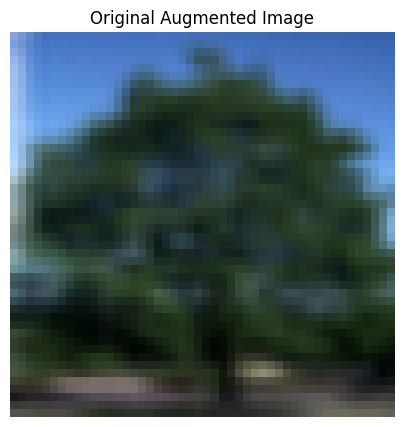

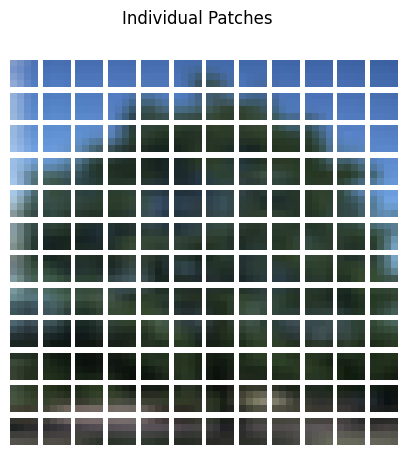

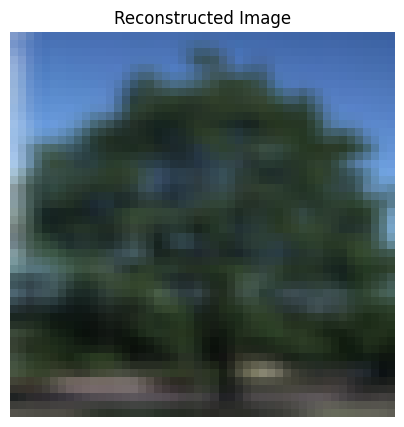

In [ ]:
# now visulizing the imgd snd hpw it would show patcjes

#get the batch of img
image_batch = next(iter(train_ds))

#agument the images
agumentation_model = get_train_agumentation_model()
agumented_images = agumentation_model(image_batch)

#define the patch layer
patch_layer = Patches()

#get the patches from the batched images
patches = patch_layer(images = agumented_images)

#passing thr img
random_index = patch_layer.show_patched_image(images = agumented_images, patches = patches)

#this choses the same chosen img and try to reconstruct the orig img
img = patch_layer.reconstruct_from_patch(patches[random_index])
plt.figure(figsize=(5,5), dpi=100) # Consistent figure size and DPI for reconstructed image
plt.imshow(img)
plt.axis("off")
plt.title("Reconstructed Image")
plt.show()

***PATCH ENCODING W MASKING***

In [ ]:
from keras import layers

# Temporarily defining parameters here for execution, should ideally be run from parameter cell
PATCH_SIZE = 4
ENC_PROJ_DIM = 192
MASK_PROPORTION = 0.90

class PatchEncoder(layers.Layer):
  def __init__(
      self,
      patch_size = PATCH_SIZE,
      projection_dim = ENC_PROJ_DIM,
      mask_proportion = MASK_PROPORTION,
      downstream = False,
      **kwargs
  ):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.projection_dim = projection_dim
    self.mask_proportion = mask_proportion
    self.downstream = downstream


    # mask the token now hehehe
    self.mask_token = tf.Variable(
        tf.random.normal([1, patch_size * patch_size * 3]),
        trainable = True,
    ) # this token will learn how the hidden patches look like

  def build(self, input_shape):
    (_, self.num_patches, self.patch_area) = input_shape

    # Create the projection layer for the patches
    self.projection = layers.Dense(units = self.projection_dim)

    # create positional embedding layer
    self.position_embedding = layers.Embedding(
        input_dim = self.num_patches,
        output_dim = self.projection_dim,
    )

    # num of patches itll mask
    self.num_mask = int(self.mask_proportion * self.num_patches)

  def call(self, patches):
    #gets the positional embeddings
    batch_size = tf.shape(patches)[0]
    positions = tf.range(start=0, limit=self.num_patches, delta = 1)
    pos_embeddings = self.position_embedding(positions[tf.newaxis,...])
    pos_embeddings = tf.tile(
        pos_embeddings, [batch_size, 1, 1]
    )

    # embedd the patches
    patch_embeddings = (
        self.projection(patches) + pos_embeddings
    )

    if self.downstream:
      return patch_embeddings

    else:
      mask_indices, unmask_indices = self.get_random_indices(batch_size)
      # selects random patches from batch and mask some and keep some unmasked

      # gathers the unmasked patches that'll be sent into the ENC
      unmasked_embeddings = tf.gather(
          patch_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      #gets the masked and unmasked position embeddings

      unmasked_positions = tf.gather(
          pos_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      mask_positions = tf.gather(
          pos_embeddings,
          mask_indices,
          axis = 1,
          batch_dims = 1,
      )

      mask_tokens = tf.repeat(self.mask_token, repeats = self.num_mask, axis = 0)
      mask_tokens = tf.repeat(
          mask_tokens[tf.newaxis, ...],
          repeats = batch_size,
          axis = 0
      )

      # creats mask embeddings for the masked tokens
      mask_embeddings = self.projection(mask_tokens) + mask_positions
                             # content of the patch + position of the patch
      return(
          unmasked_embeddings, # sent to rnc
          mask_embeddings, # sent to dec
          unmasked_positions, # sent to dec
          mask_indices, #dec
          unmask_indices, # dec
      )

  def get_random_indices(self, batch_size):
        # Create random indices from a uniform distribution and then split
        # it into mask and unmask indices.
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

  def generate_masked_image(self, patches, unmask_indices):
        # Choose a random patch and it corresponding unmask index.
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]

        # Build a numpy array of same shape as patch.
        new_patch = np.zeros_like(patch)

        # Iterate of the new_patch and plug the unmasked patches.
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

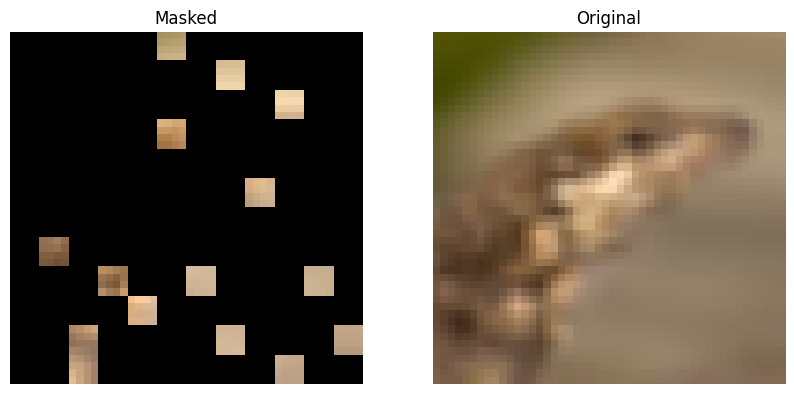

In [ ]:
# Create the patch encoder layer.
patch_encoder = PatchEncoder()

# Get the embeddings and positions.
(
    unmasked_embeddings,
    masked_embeddings,
    unmasked_positions,
    mask_indices,
    unmask_indices,
) = patch_encoder(patches=patches)


# Show a maksed patch image.
new_patch, random_index = patch_encoder.generate_masked_image(patches, unmask_indices)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
img = patch_layer.reconstruct_from_patch(new_patch)
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Masked")
plt.subplot(1, 2, 2)
img = agumented_images[random_index]
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Original")
plt.show()

***MLP***

In [ ]:
def mlp(x, dropout_rate, hidden_units):
  for units in hidden_units:
    x = layers.Dense(units, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout_rate)(x)
  return x

***MAE ENCODER***

In [ ]:
import keras
from keras import layers

ENC_PROECTION_DIM = 192
ENC_NUM_HEADS = 6
ENC_LAYERS = 10
DROPOUT_RATE = 0.1
LAYER_NORM_EPS = 1e-6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]


def create_encoder():
  inputs = layers.Input(shape = (None, ENC_PROJ_DIM))
  x = inputs

  for _ in range(ENC_LAYERS):

    # 1. layer norm
    x1 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    # 2, attention
    attention_output = layers.MultiHeadAttention(
        num_heads = ENC_NUM_HEADS,
        key_dim = ENC_PROJ_DIM // ENC_NUM_HEADS,
        dropout = DROPOUT_RATE,
    )(x1, x1)

    attention_output = layers.Dropout(DROPOUT_RATE)(attention_output)

    # 3. residual
    x2 = layers.Add()([x, attention_output])

    # 4. layer norm
    x3 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x2)

    x3 = mlp(x3, hidden_units = ENC_TRANSFORMER_UNITS, dropout_rate = DROPOUT_RATE,)

    x = layers.Add()([x2, x3])

    outputs = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    return keras.Model(inputs, outputs, name = "mae_enc_strong")



In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=0.05
)


***DECODER***

In [ ]:
import keras
from keras import layers
import tensorflow as tf

# ===============================
# Production-Level Decoder
# ===============================
def create_decoder():

    inputs = layers.Input((NUM_PATCHES, ENC_PROJ_DIM))

    # Project encoder dim → decoder dim
    x = layers.Dense(DEC_PROJ_DIM)(inputs)

    # Positional embedding for decoder
    positions = tf.range(start=0, limit=NUM_PATCHES, delta=1)
    pos_embedding = layers.Embedding(
        input_dim=NUM_PATCHES,
        output_dim=DEC_PROJ_DIM
    )(positions)

    x = x + pos_embedding

    # Transformer blocks
    for _ in range(DEC_LAYERS):

        # Pre-Norm Attention
        x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

        attn_output = layers.MultiHeadAttention(
            num_heads=DEC_NUM_HEADS,
            key_dim=DEC_PROJ_DIM // DEC_NUM_HEADS,
            dropout=DROPOUT_RATE,
        )(x1, x1)

        attn_output = layers.Dropout(DROPOUT_RATE)(attn_output)

        x2 = layers.Add()([x, attn_output])

        # Pre-Norm MLP
        x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

        x3 = mlp(
            x3,
            hidden_units=DEC_TRANSFORMER_UNITS,
            dropout_rate=DROPOUT_RATE,
        )

        x = layers.Add()([x2, x3])

    x = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

    # Reconstruct patches
    patch_outputs = layers.Dense(PATCH_AREA)(x)

    # Convert patches → image
    outputs = layers.Reshape(
        (IMAGE_SIZE // PATCH_SIZE,
         IMAGE_SIZE // PATCH_SIZE,
         PATCH_SIZE,
         PATCH_SIZE,
         3)
    )(patch_outputs)

    outputs = layers.Lambda(lambda x: tf.transpose(x, perm=[0,1,3,2,4,5]))(outputs)
    outputs = layers.Reshape((IMAGE_SIZE, IMAGE_SIZE, 3))(outputs)

    return keras.Model(inputs, outputs, name="mae_decoder_strong")

***MAE TRAINER***

In [ ]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        test_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.test_augmentation_model = test_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def calculate_loss(self, images, test=False):
        # Augment the input images.
        if test:
            augmented_images = self.test_augmentation_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        # Patch the augmented images.
        patches = self.patch_layer(augmented_images)

        # Encode the patches.
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        # Compute the total loss.
        total_loss = self.compute_loss(y=loss_patch, y_pred=loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        # Apply gradients.
        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)

        # Report progress.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)

        # Update the trackers.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results


In [ ]:
# Instantiate the models
train_augmentation_model = get_train_agumentation_model()
test_augmentation_model = get_test_agumentation_model()
patch_layer = Patches()
patch_encoder = PatchEncoder()
encoder = create_encoder()
decoder = create_decoder()

mae_model = MaskedAutoencoder(
    train_augmentation_model=train_augmentation_model,
    test_augmentation_model=test_augmentation_model,
    patch_layer=patch_layer,
    patch_encoder=patch_encoder,
    encoder=encoder,
    decoder=decoder,
)

***TRAINING CALLBACKS***

In [ ]:
# Taking a batch of test inputs to measure model's progress.
test_images = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            test_augmented_images = self.model.test_augmentation_model(test_images)
            test_patches = self.model.patch_layer(test_augmented_images)
            (
                test_unmasked_embeddings,
                test_masked_embeddings,
                test_unmasked_positions,
                test_mask_indices,
                test_unmask_indices,
            ) = self.model.patch_encoder(test_patches)
            test_encoder_outputs = self.model.encoder(test_unmasked_embeddings)
            test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
            test_decoder_inputs = tf.concat(
                [test_encoder_outputs, test_masked_embeddings], axis=1
            )
            test_decoder_outputs = self.model.decoder(test_decoder_inputs)

            # Show a maksed patch image.
            test_masked_patch, idx = self.model.patch_encoder.generate_masked_image(
                test_patches, test_unmask_indices
            )
            print(f"\nIdx chosen: {idx}")
            original_image = test_augmented_images[idx]
            masked_image = self.model.patch_layer.reconstruct_from_patch(
                test_masked_patch
            )
            reconstructed_image = test_decoder_outputs[idx]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
            ax[0].imshow(original_image)
            ax[0].set_title(f"Original: {epoch:03d}")

            ax[1].imshow(masked_image)
            ax[1].set_title(f"Masked: {epoch:03d}")

            ax[2].imshow(reconstructed_image)
            ax[2].set_title(f"Resonstructed: {epoch:03d}")

            plt.show()
            plt.close()


In [ ]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Warmup
        warmup_lr = self.base_lr * (step / self.warmup_steps)

        # Cosine decay
        cosine_lr = 0.5 * self.base_lr * (
            1 + tf.cos(
                self.pi * (step - self.warmup_steps) /
                (self.total_steps - self.warmup_steps)
            )
        )

        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)


total_steps = int((len(x_train) / BATCH_SIZE) * EPOCHS)
warmup_steps = int(total_steps * 0.25)   # 🔥 25% warmup for 90% masking

lr_schedule = WarmUpCosine(
    base_lr=5e-4,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

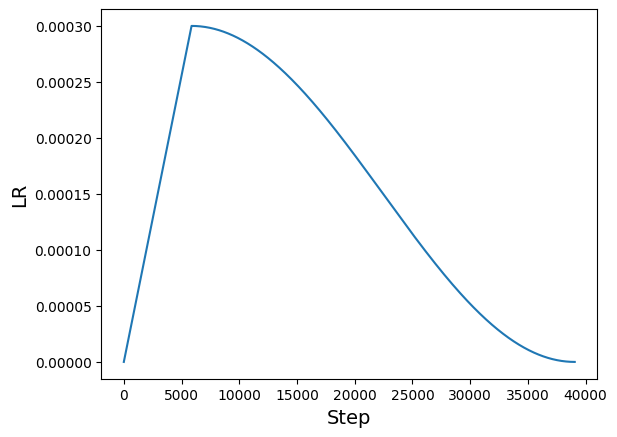

In [ ]:
total_steps = int((len(x_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    base_lr=LEARNING_RATE,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

lrs = [scheduled_lrs(step) for step in range(total_steps)]
plt.plot(lrs)
plt.xlabel("Step", fontsize=14)
plt.ylabel("LR", fontsize=14)
plt.show()

# Assemble the callbacks.
train_callbacks = [TrainMonitor(epoch_interval=5)]

In [ ]:
mae_model.compile(optimizer=optimizer, metrics=[keras.metrics.MeanSquaredError()])

Understanding the Curve:

Warm-up Phase (Initial Increase): You can see that the learning rate starts from 0 and gradually increases over the initial steps. This is called a "warm-up" phase. It's a common practice in deep learning, especially with large models, to start with a very low learning rate and slowly increase it. This helps to stabilize training at the beginning, preventing large gradient updates that could lead to unstable initial weights.

In your specific setup, the warmup_steps were calculated as 15% of the total_steps, meaning the learning rate will linearly increase for the first 15% of the training duration.
Cosine Decay (Gradual Decrease): After the warm-up phase, the learning rate follows a cosine-like curve, gradually decreasing from its peak down to near zero. This is known as a "cosine decay" learning rate schedule. The idea is to allow the model to make larger progress during the middle of training and then fine-tune its weights with smaller steps as it approaches convergence towards the end.

Using a decaying learning rate helps the model to escape local minima and settle into a good solution by the end of training.

Epoch 1/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - mae: 0.9299 - loss: 0.9059


Idx chosen: 102


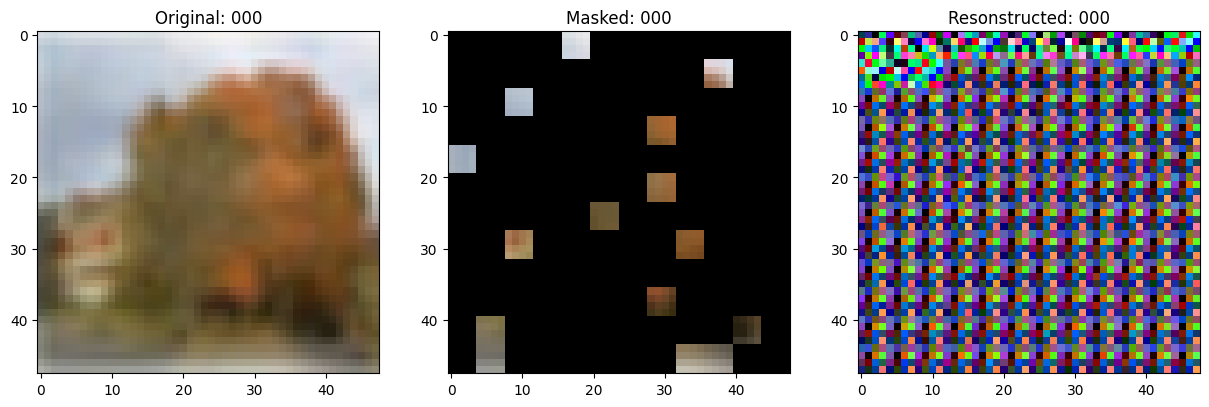

157/157 ━━━━━━━━━━━━━━━━━━━━ 88s 397ms/step - mae: 0.9264 - loss: 0.9030 - val_loss: 0.4771
Epoch 2/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.2948 - loss: 0.4752 - val_loss: 0.4814
Epoch 3/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 374ms/step - mae: 0.2233 - loss: 0.4785 - val_loss: 0.4830
Epoch 4/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.2168 - loss: 0.4802 - val_loss: 0.4850
Epoch 5/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.2104 - loss: 0.4839 - val_loss: 0.4997
Epoch 6/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - mae: 0.1936 - loss: 0.4992
Idx chosen: 179


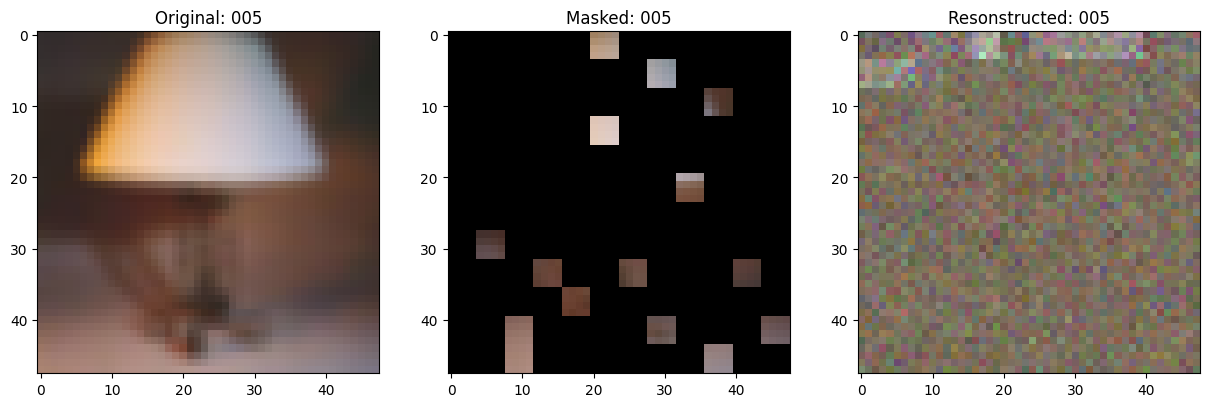

157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1935 - loss: 0.4992 - val_loss: 0.5146
Epoch 7/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1817 - loss: 0.5116 - val_loss: 0.5223
Epoch 8/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1757 - loss: 0.5170 - val_loss: 0.5250
Epoch 9/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1726 - loss: 0.5192 - val_loss: 0.5258
Epoch 10/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1703 - loss: 0.5210 - val_loss: 0.5280
Epoch 11/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - mae: 0.1684 - loss: 0.5227
Idx chosen: 92


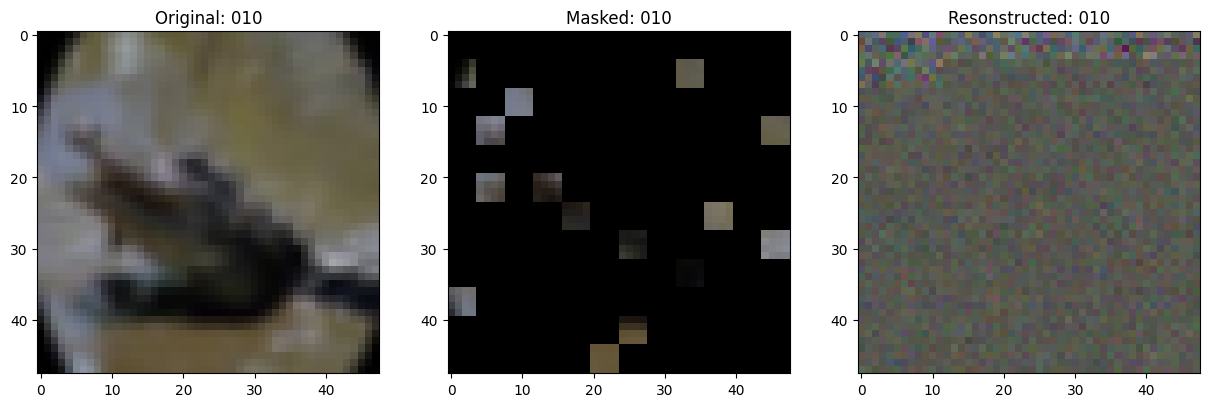

157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1685 - loss: 0.5227 - val_loss: 0.5285
Epoch 12/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1669 - loss: 0.5239 - val_loss: 0.5312
Epoch 13/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1656 - loss: 0.5251 - val_loss: 0.5321
Epoch 14/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1648 - loss: 0.5262 - val_loss: 0.5339
Epoch 15/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1633 - loss: 0.5267 - val_loss: 0.5346
Epoch 16/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - mae: 0.1624 - loss: 0.5272


Idx chosen: 14


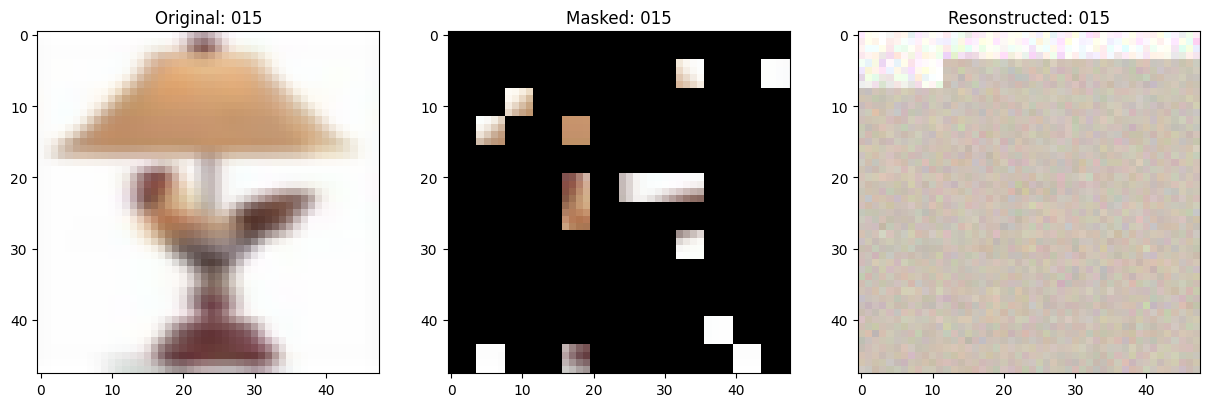

157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1624 - loss: 0.5272 - val_loss: 0.5348
Epoch 17/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1619 - loss: 0.5279 - val_loss: 0.5326
Epoch 18/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1611 - loss: 0.5278 - val_loss: 0.5349
Epoch 19/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1606 - loss: 0.5286 - val_loss: 0.5365
Epoch 20/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1601 - loss: 0.5288 - val_loss: 0.5350
Epoch 21/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - mae: 0.1596 - loss: 0.5294
Idx chosen: 106


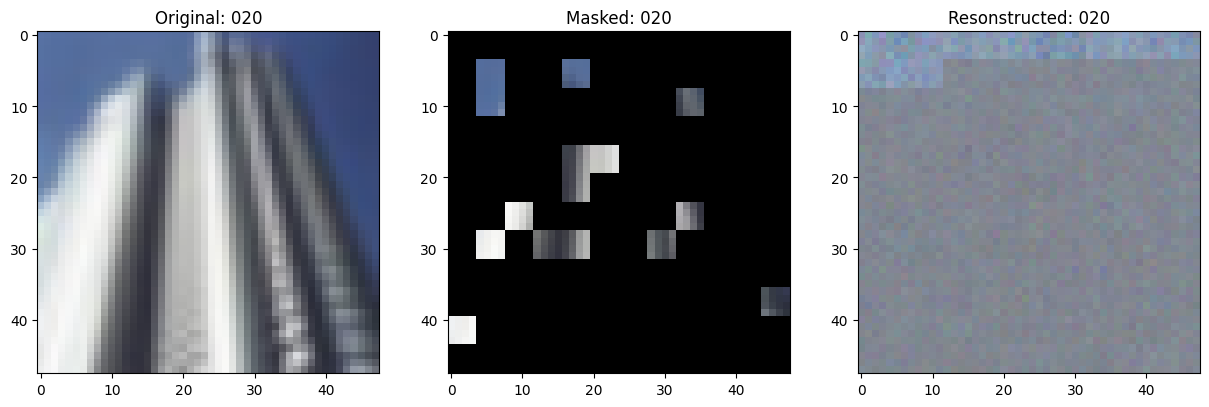

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1596 - loss: 0.5294 - val_loss: 0.5369
Epoch 22/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1594 - loss: 0.5295 - val_loss: 0.5378
Epoch 23/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1591 - loss: 0.5303 - val_loss: 0.5366
Epoch 24/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1587 - loss: 0.5295 - val_loss: 0.5397
Epoch 25/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1587 - loss: 0.5307 - val_loss: 0.5342
Epoch 26/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - mae: 0.1583 - loss: 0.5298
Idx chosen: 71


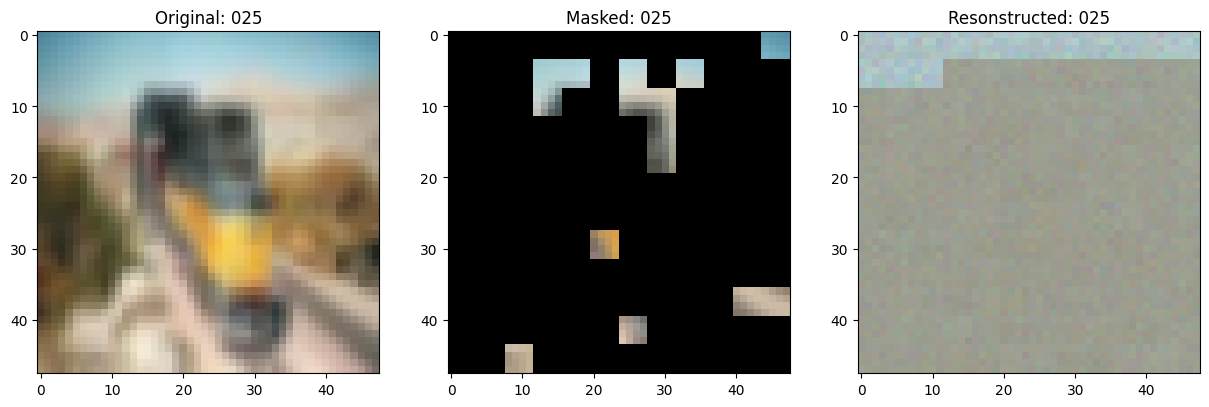

157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1583 - loss: 0.5298 - val_loss: 0.5363
Epoch 27/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1580 - loss: 0.5304 - val_loss: 0.5361
Epoch 28/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1581 - loss: 0.5304 - val_loss: 0.5352
Epoch 29/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1577 - loss: 0.5304 - val_loss: 0.5364
Epoch 30/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1578 - loss: 0.5310 - val_loss: 0.5357
Epoch 31/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - mae: 0.1576 - loss: 0.5310
Idx chosen: 188


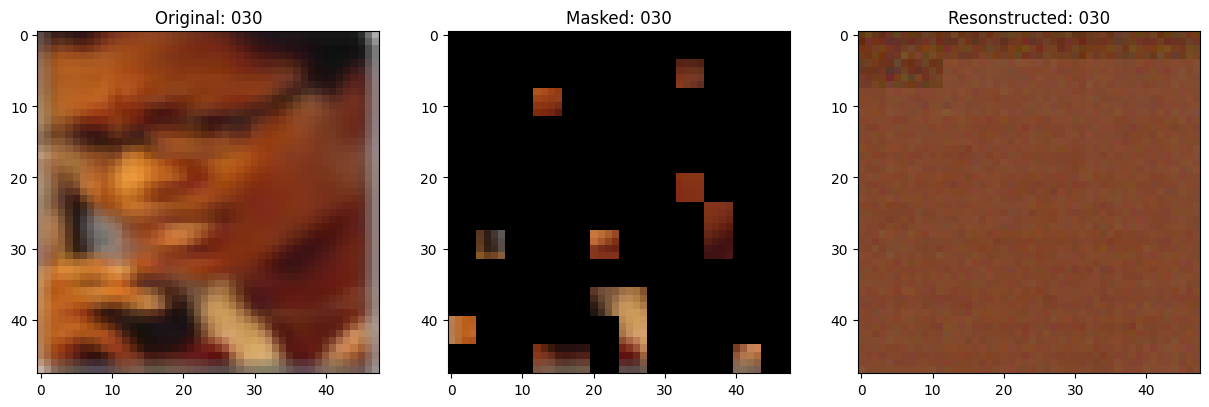

157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1576 - loss: 0.5310 - val_loss: 0.5387
Epoch 32/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1572 - loss: 0.5312 - val_loss: 0.5384
Epoch 33/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 383ms/step - mae: 0.1570 - loss: 0.5317 - val_loss: 0.5363
Epoch 34/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 373ms/step - mae: 0.1574 - loss: 0.5305 - val_loss: 0.5405
Epoch 35/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1573 - loss: 0.5311 - val_loss: 0.5383
Epoch 36/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - mae: 0.1569 - loss: 0.5319
Idx chosen: 20


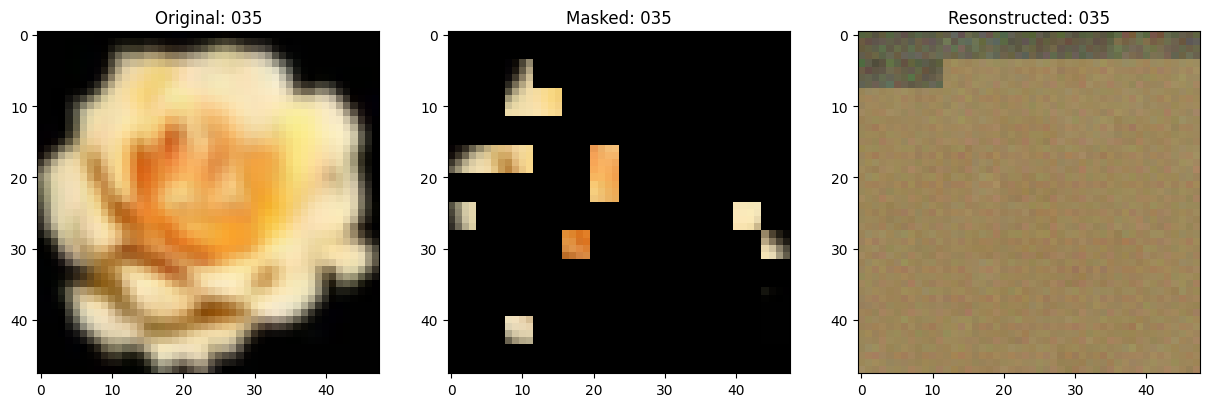

157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1569 - loss: 0.5319 - val_loss: 0.5389
Epoch 37/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1567 - loss: 0.5318 - val_loss: 0.5416
Epoch 38/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - mae: 0.1545 - loss: 0.5339 - val_loss: 0.5434
Epoch 39/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1520 - loss: 0.5359 - val_loss: 0.5465
Epoch 40/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1507 - loss: 0.5368 - val_loss: 0.5433
Epoch 41/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - mae: 0.1494 - loss: 0.5376
Idx chosen: 102


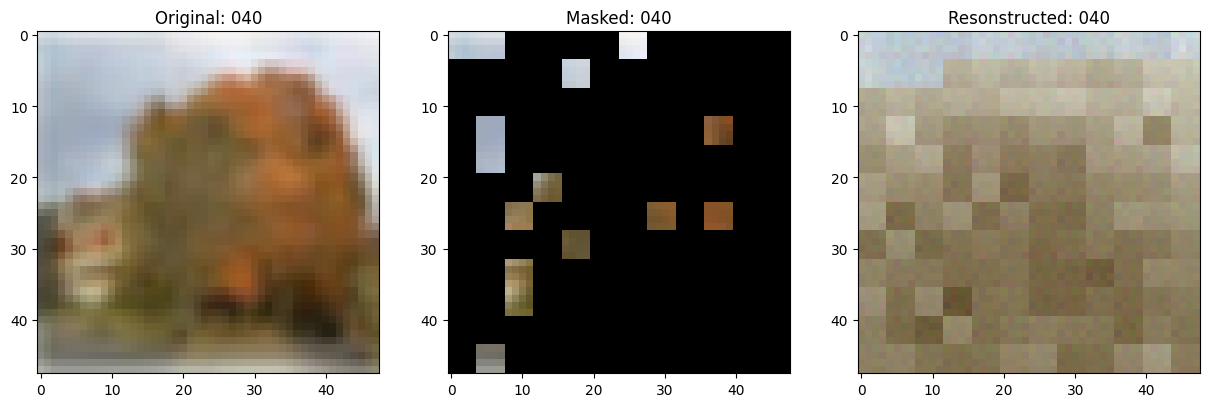

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.1494 - loss: 0.5376 - val_loss: 0.5477
Epoch 42/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1481 - loss: 0.5397 - val_loss: 0.5480
Epoch 43/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 377ms/step - mae: 0.1458 - loss: 0.5414 - val_loss: 0.5544
Epoch 44/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1429 - loss: 0.5438 - val_loss: 0.5567
Epoch 45/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1412 - loss: 0.5450 - val_loss: 0.5530
Epoch 46/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - mae: 0.1395 - loss: 0.5456
Idx chosen: 121


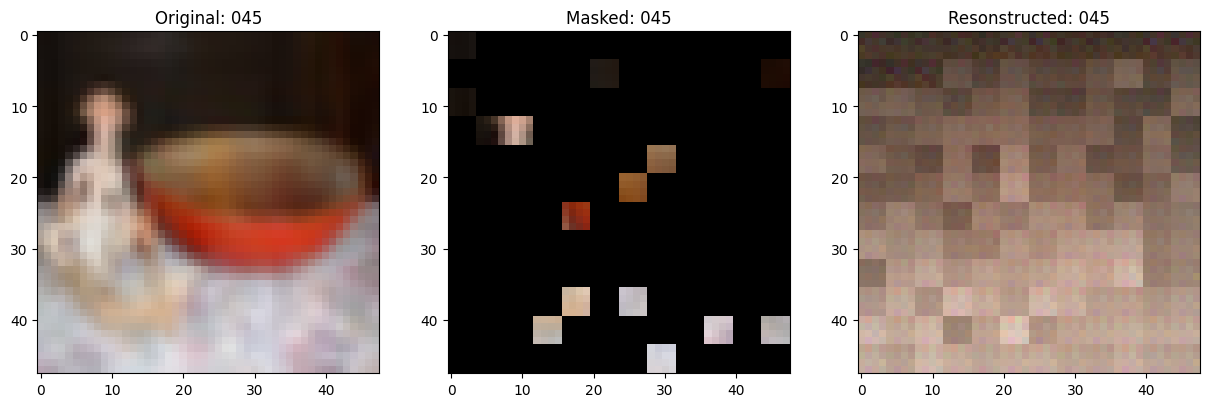

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1395 - loss: 0.5456 - val_loss: 0.5483
Epoch 47/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1395 - loss: 0.5459 - val_loss: 0.5586
Epoch 48/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 377ms/step - mae: 0.1376 - loss: 0.5480 - val_loss: 0.5561
Epoch 49/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1364 - loss: 0.5483 - val_loss: 0.5555
Epoch 50/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1351 - loss: 0.5502 - val_loss: 0.5543
Epoch 51/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - mae: 0.1345 - loss: 0.5503


Idx chosen: 210


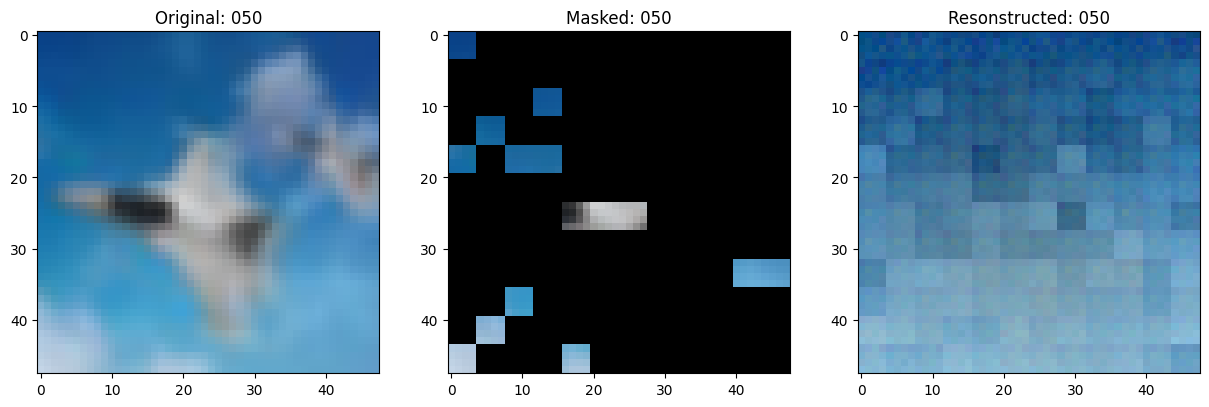

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 379ms/step - mae: 0.1345 - loss: 0.5503 - val_loss: 0.5577
Epoch 52/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1330 - loss: 0.5518 - val_loss: 0.5598
Epoch 53/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1315 - loss: 0.5520 - val_loss: 0.5556
Epoch 54/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1308 - loss: 0.5531 - val_loss: 0.5590
Epoch 55/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - mae: 0.1285 - loss: 0.5545 - val_loss: 0.5603
Epoch 56/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - mae: 0.1269 - loss: 0.5566
Idx chosen: 214


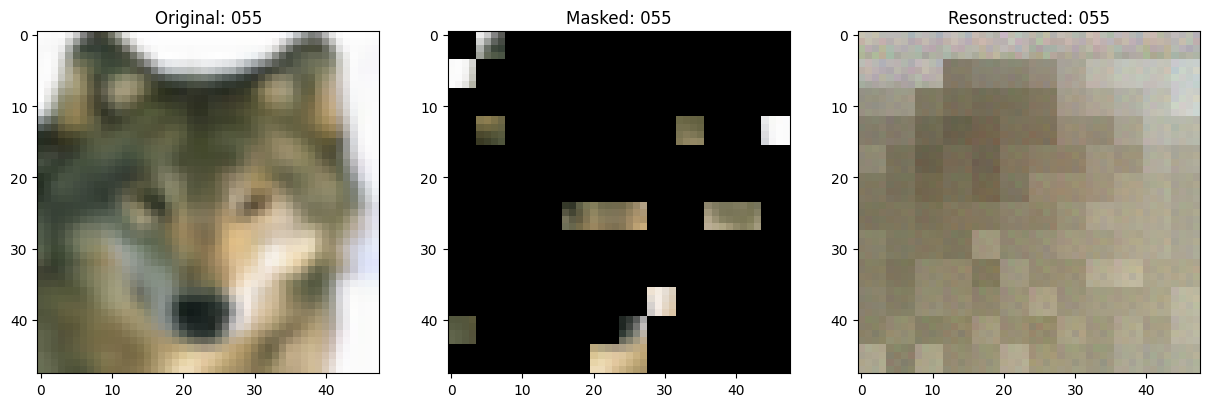

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.1269 - loss: 0.5566 - val_loss: 0.5612
Epoch 57/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1253 - loss: 0.5570 - val_loss: 0.5619
Epoch 58/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1240 - loss: 0.5582 - val_loss: 0.5632
Epoch 59/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1222 - loss: 0.5592 - val_loss: 0.5653
Epoch 60/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 379ms/step - mae: 0.1207 - loss: 0.5603 - val_loss: 0.5662
Epoch 61/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - mae: 0.1193 - loss: 0.5613


Idx chosen: 74


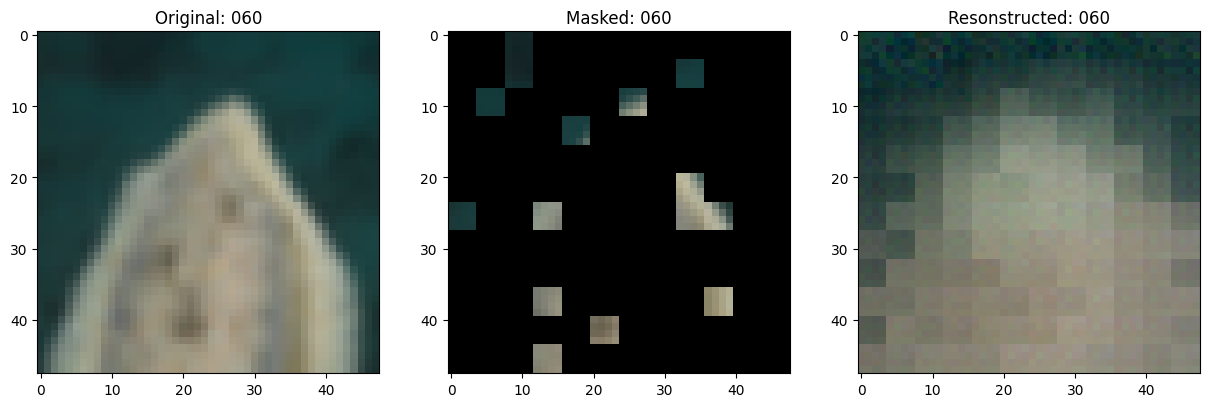

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.1193 - loss: 0.5613 - val_loss: 0.5690
Epoch 62/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1174 - loss: 0.5626 - val_loss: 0.5743
Epoch 63/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 379ms/step - mae: 0.1171 - loss: 0.5630 - val_loss: 0.5694
Epoch 64/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - mae: 0.1156 - loss: 0.5631 - val_loss: 0.5733
Epoch 65/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1149 - loss: 0.5643 - val_loss: 0.5666
Epoch 66/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - mae: 0.1146 - loss: 0.5652
Idx chosen: 202


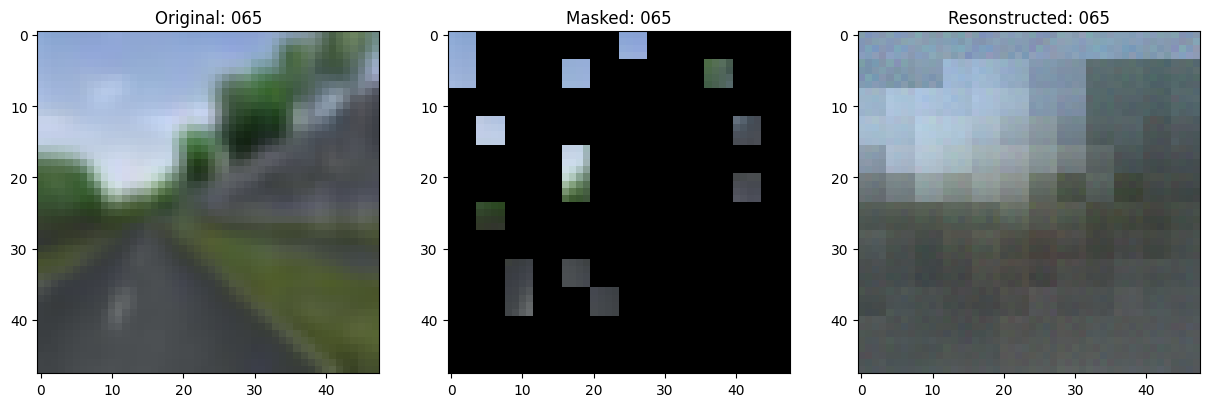

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.1146 - loss: 0.5652 - val_loss: 0.5722
Epoch 67/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1125 - loss: 0.5658 - val_loss: 0.5742
Epoch 68/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1117 - loss: 0.5658 - val_loss: 0.5740
Epoch 69/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1100 - loss: 0.5680 - val_loss: 0.5818
Epoch 70/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1086 - loss: 0.5686 - val_loss: 0.5770
Epoch 71/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - mae: 0.1071 - loss: 0.5696
Idx chosen: 87


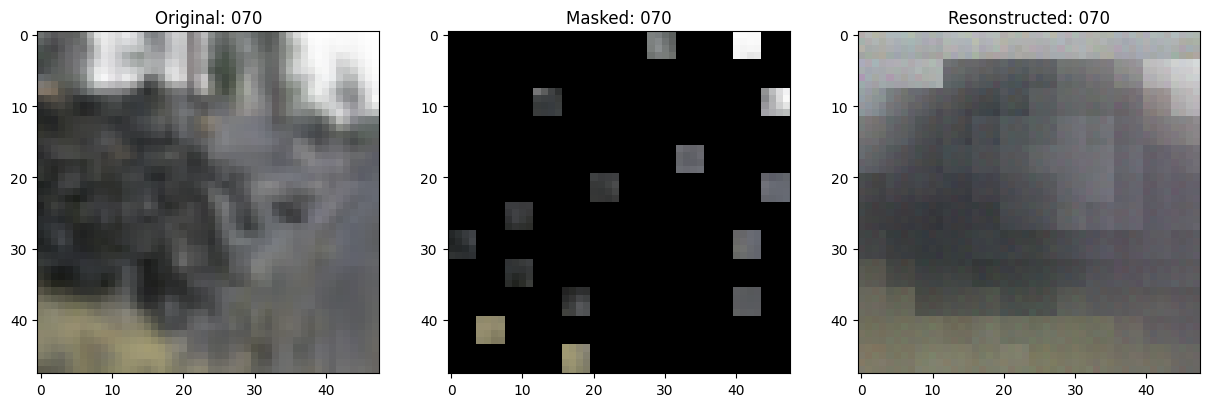

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.1071 - loss: 0.5696 - val_loss: 0.5754
Epoch 72/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1064 - loss: 0.5694 - val_loss: 0.5773
Epoch 73/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 379ms/step - mae: 0.1060 - loss: 0.5698 - val_loss: 0.5735
Epoch 74/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.1049 - loss: 0.5702 - val_loss: 0.5798
Epoch 75/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.1037 - loss: 0.5715 - val_loss: 0.5781
Epoch 76/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - mae: 0.1033 - loss: 0.5722


Idx chosen: 116


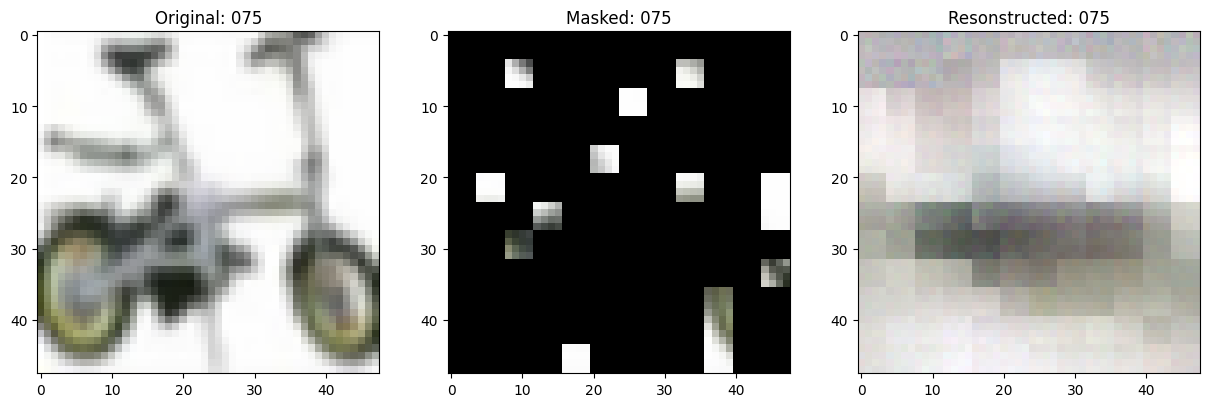

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.1033 - loss: 0.5722 - val_loss: 0.5744
Epoch 77/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 379ms/step - mae: 0.1026 - loss: 0.5725 - val_loss: 0.5786
Epoch 78/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.1018 - loss: 0.5725 - val_loss: 0.5820
Epoch 79/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.1018 - loss: 0.5732 - val_loss: 0.5844
Epoch 80/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.1010 - loss: 0.5733 - val_loss: 0.5853
Epoch 81/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - mae: 0.1005 - loss: 0.5739
Idx chosen: 99


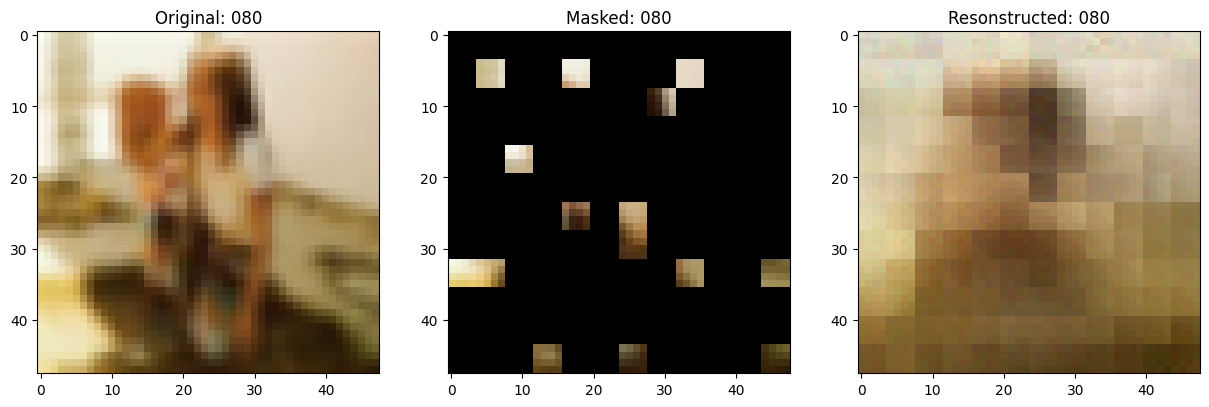

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.1005 - loss: 0.5739 - val_loss: 0.5828
Epoch 82/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0997 - loss: 0.5739 - val_loss: 0.5806
Epoch 83/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.0998 - loss: 0.5729 - val_loss: 0.5806
Epoch 84/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0995 - loss: 0.5738 - val_loss: 0.5828
Epoch 85/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0989 - loss: 0.5737 - val_loss: 0.5815
Epoch 86/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - mae: 0.0985 - loss: 0.5746
Idx chosen: 103


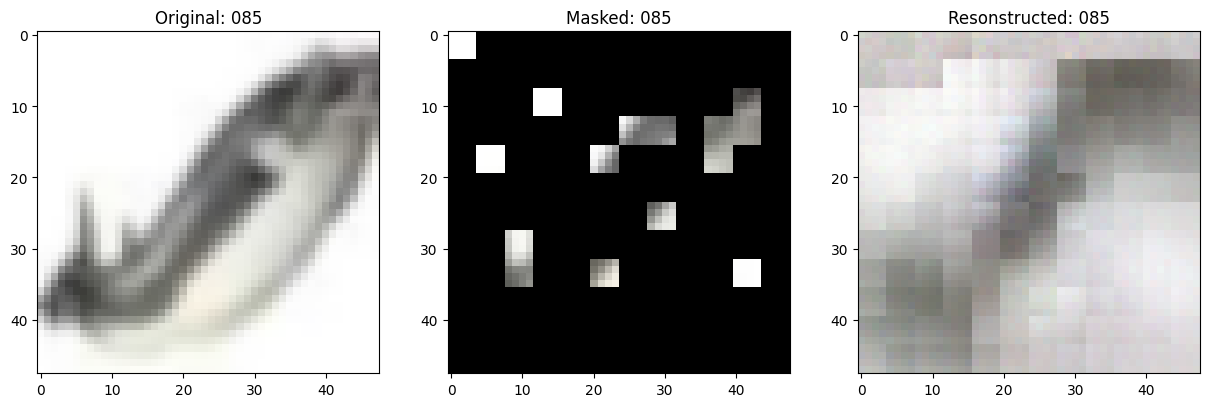

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0985 - loss: 0.5746 - val_loss: 0.5829
Epoch 87/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0977 - loss: 0.5752 - val_loss: 0.5815
Epoch 88/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.0976 - loss: 0.5751 - val_loss: 0.5817
Epoch 89/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0976 - loss: 0.5748 - val_loss: 0.5816
Epoch 90/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0974 - loss: 0.5753 - val_loss: 0.5854
Epoch 91/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - mae: 0.0975 - loss: 0.5752
Idx chosen: 151


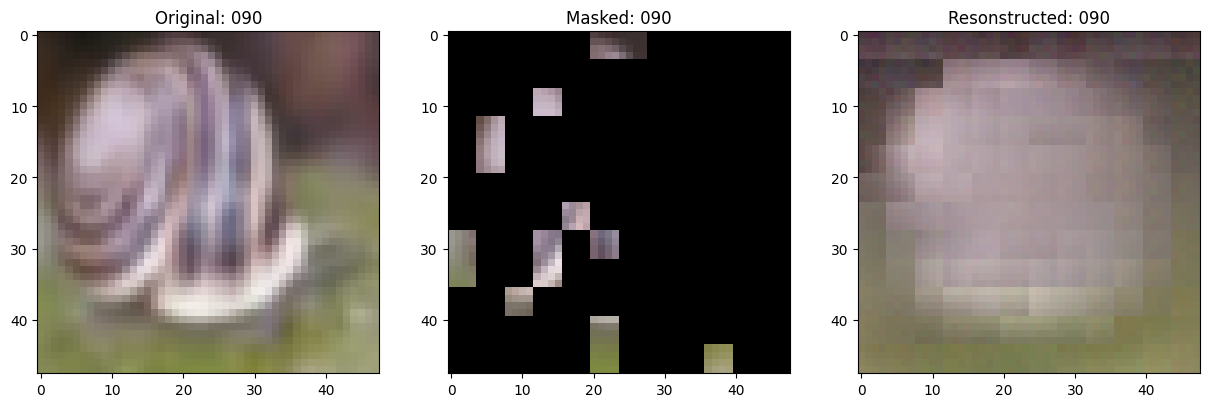

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0975 - loss: 0.5752 - val_loss: 0.5831
Epoch 92/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0969 - loss: 0.5755 - val_loss: 0.5827
Epoch 93/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0964 - loss: 0.5755 - val_loss: 0.5856
Epoch 94/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0960 - loss: 0.5760 - val_loss: 0.5837
Epoch 95/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0962 - loss: 0.5759 - val_loss: 0.5844
Epoch 96/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - mae: 0.0960 - loss: 0.5758


Idx chosen: 130


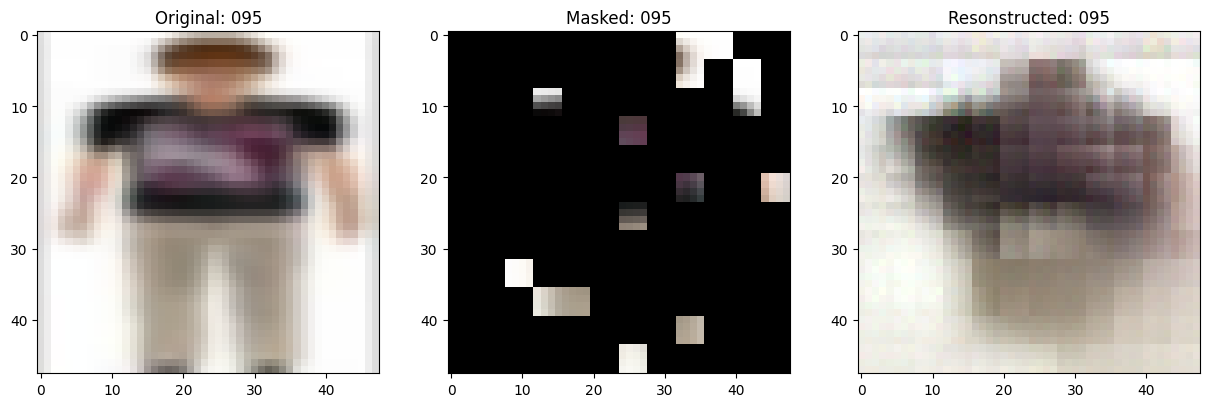

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0961 - loss: 0.5758 - val_loss: 0.5833
Epoch 97/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0962 - loss: 0.5750 - val_loss: 0.5812
Epoch 98/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 389ms/step - mae: 0.0958 - loss: 0.5762 - val_loss: 0.5852
Epoch 99/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - mae: 0.0951 - loss: 0.5765 - val_loss: 0.5811
Epoch 100/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0955 - loss: 0.5764 - val_loss: 0.5819
Epoch 101/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - mae: 0.0951 - loss: 0.5762
Idx chosen: 149


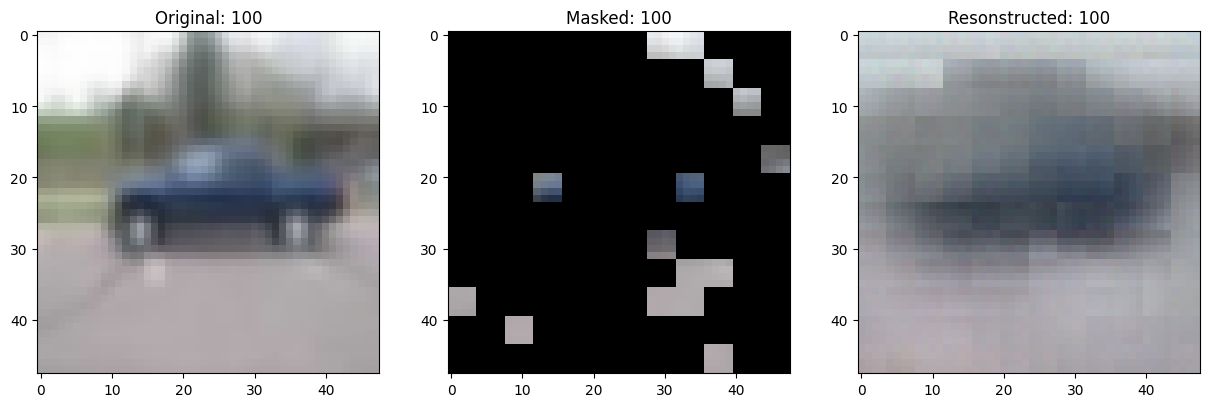

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0951 - loss: 0.5762 - val_loss: 0.5826
Epoch 102/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0949 - loss: 0.5761 - val_loss: 0.5840
Epoch 103/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0947 - loss: 0.5772 - val_loss: 0.5821
Epoch 104/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0947 - loss: 0.5773 - val_loss: 0.5867
Epoch 105/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0946 - loss: 0.5771 - val_loss: 0.5841
Epoch 106/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - mae: 0.0945 - loss: 0.5762
Idx chosen: 52


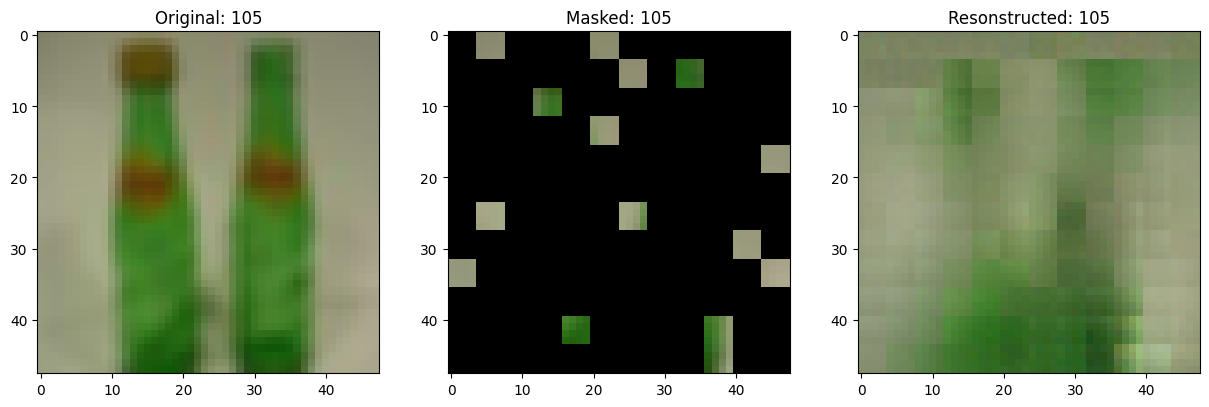

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0945 - loss: 0.5762 - val_loss: 0.5857
Epoch 107/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0940 - loss: 0.5772 - val_loss: 0.5862
Epoch 108/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0939 - loss: 0.5775 - val_loss: 0.5858
Epoch 109/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0936 - loss: 0.5772 - val_loss: 0.5852
Epoch 110/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0937 - loss: 0.5775 - val_loss: 0.5828
Epoch 111/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - mae: 0.0938 - loss: 0.5778
Idx chosen: 1


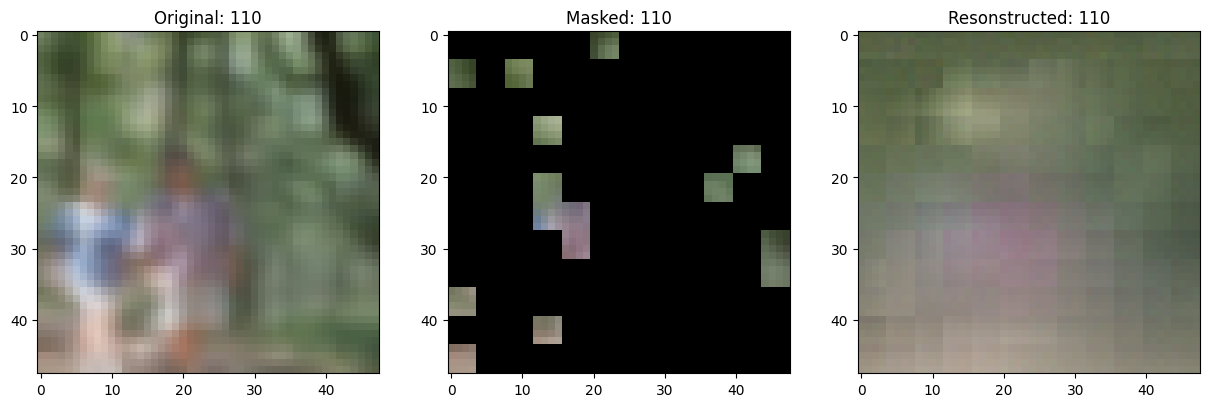

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0938 - loss: 0.5778 - val_loss: 0.5815
Epoch 112/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0935 - loss: 0.5769 - val_loss: 0.5861
Epoch 113/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0930 - loss: 0.5786 - val_loss: 0.5852
Epoch 114/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0929 - loss: 0.5775 - val_loss: 0.5860
Epoch 115/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0932 - loss: 0.5778 - val_loss: 0.5855
Epoch 116/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - mae: 0.0930 - loss: 0.5777


Idx chosen: 87


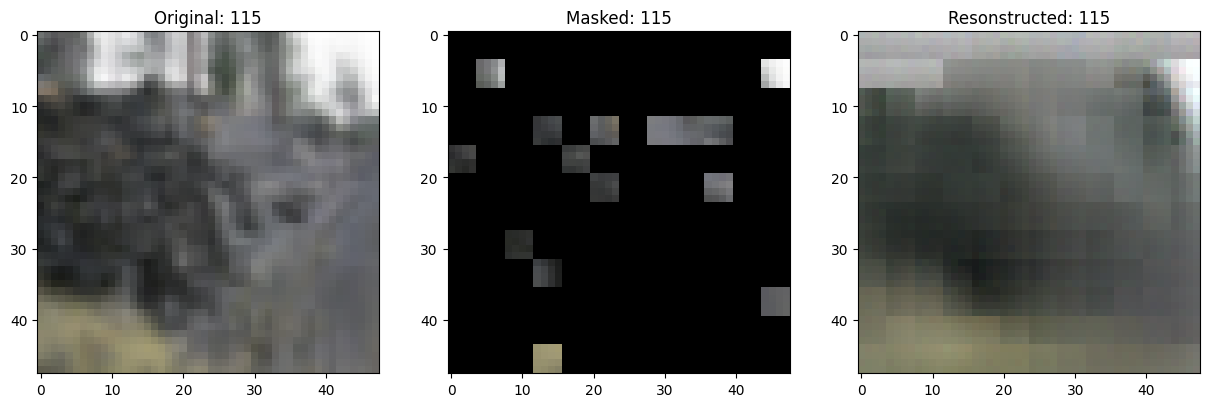

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0930 - loss: 0.5777 - val_loss: 0.5869
Epoch 117/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0931 - loss: 0.5780 - val_loss: 0.5814
Epoch 118/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0930 - loss: 0.5773 - val_loss: 0.5869
Epoch 119/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 389ms/step - mae: 0.0928 - loss: 0.5773 - val_loss: 0.5887
Epoch 120/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - mae: 0.0931 - loss: 0.5776 - val_loss: 0.5852
Epoch 121/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - mae: 0.0925 - loss: 0.5780


Idx chosen: 235


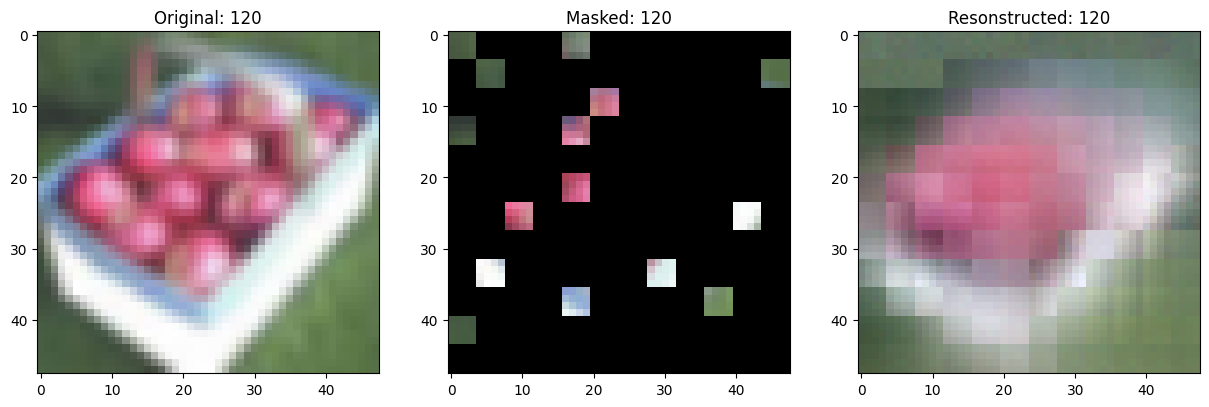

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0926 - loss: 0.5780 - val_loss: 0.5848
Epoch 122/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0925 - loss: 0.5781 - val_loss: 0.5844
Epoch 123/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0921 - loss: 0.5788 - val_loss: 0.5882
Epoch 124/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0929 - loss: 0.5786 - val_loss: 0.5826
Epoch 125/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0921 - loss: 0.5787 - val_loss: 0.5868
Epoch 126/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - mae: 0.0917 - loss: 0.5786


Idx chosen: 157


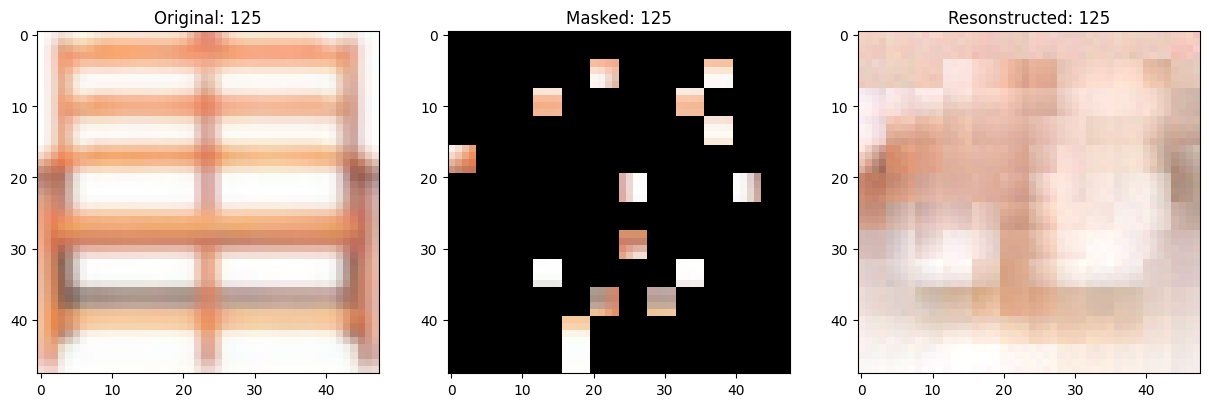

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0917 - loss: 0.5786 - val_loss: 0.5871
Epoch 127/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0920 - loss: 0.5780 - val_loss: 0.5863
Epoch 128/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0919 - loss: 0.5786 - val_loss: 0.5854
Epoch 129/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0919 - loss: 0.5780 - val_loss: 0.5812
Epoch 130/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0920 - loss: 0.5789 - val_loss: 0.5866
Epoch 131/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - mae: 0.0917 - loss: 0.5780
Idx chosen: 37


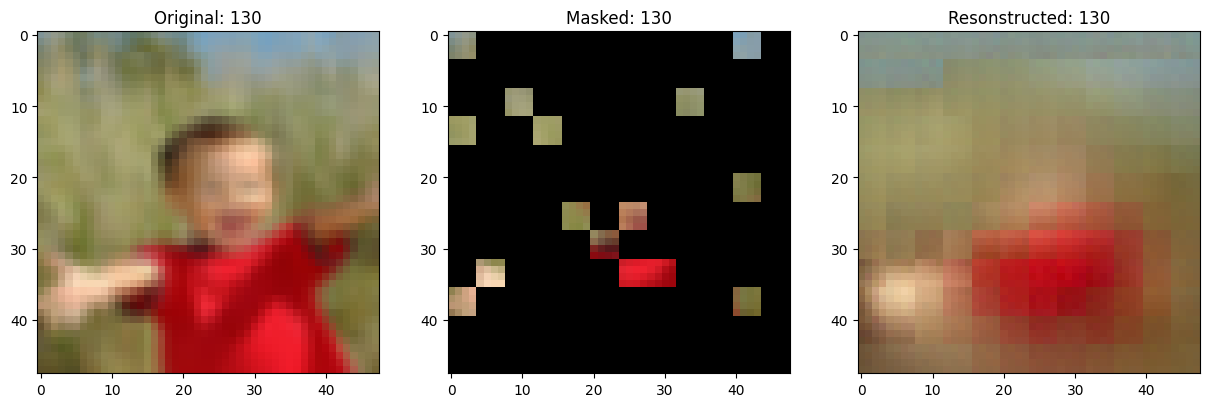

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0917 - loss: 0.5780 - val_loss: 0.5883
Epoch 132/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0916 - loss: 0.5788 - val_loss: 0.5895
Epoch 133/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - mae: 0.0916 - loss: 0.5786 - val_loss: 0.5849
Epoch 134/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - mae: 0.0914 - loss: 0.5788 - val_loss: 0.5863
Epoch 135/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0912 - loss: 0.5794 - val_loss: 0.5870
Epoch 136/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - mae: 0.0912 - loss: 0.5789
Idx chosen: 129


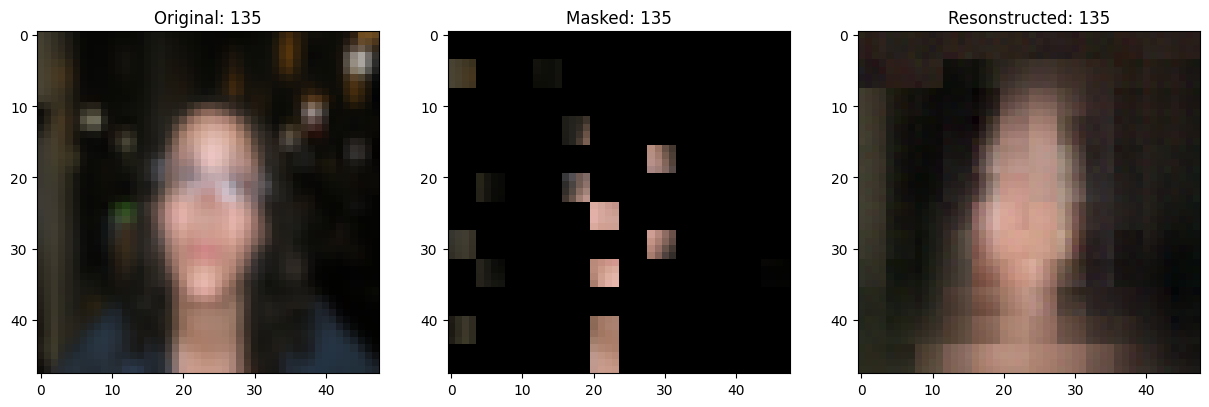

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0912 - loss: 0.5789 - val_loss: 0.5846
Epoch 137/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0910 - loss: 0.5786 - val_loss: 0.5874
Epoch 138/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0913 - loss: 0.5787 - val_loss: 0.5877
Epoch 139/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0910 - loss: 0.5794 - val_loss: 0.5870
Epoch 140/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0908 - loss: 0.5786 - val_loss: 0.5849
Epoch 141/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0905 - loss: 0.5784


Idx chosen: 191


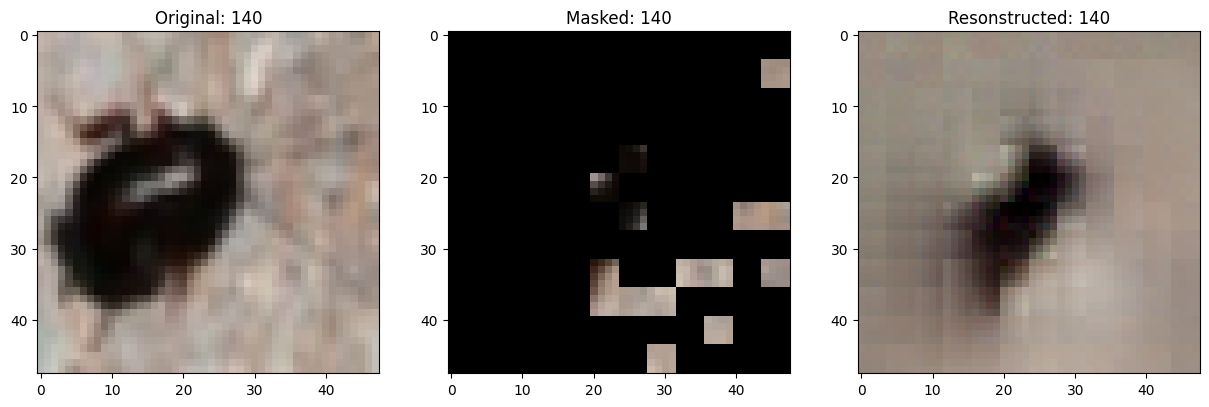

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - mae: 0.0905 - loss: 0.5784 - val_loss: 0.5870
Epoch 142/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0912 - loss: 0.5785 - val_loss: 0.5856
Epoch 143/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0906 - loss: 0.5795 - val_loss: 0.5858
Epoch 144/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0905 - loss: 0.5796 - val_loss: 0.5867
Epoch 145/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0905 - loss: 0.5795 - val_loss: 0.5867
Epoch 146/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - mae: 0.0903 - loss: 0.5794
Idx chosen: 187


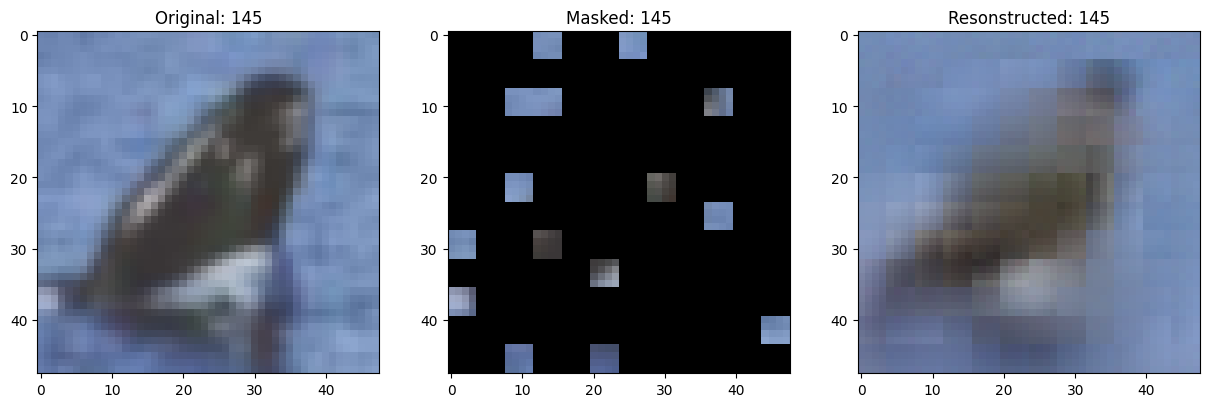

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 391ms/step - mae: 0.0903 - loss: 0.5794 - val_loss: 0.5881
Epoch 147/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 393ms/step - mae: 0.0905 - loss: 0.5787 - val_loss: 0.5869
Epoch 148/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0901 - loss: 0.5804 - val_loss: 0.5895
Epoch 149/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 386ms/step - mae: 0.0906 - loss: 0.5789 - val_loss: 0.5861
Epoch 150/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0903 - loss: 0.5795 - val_loss: 0.5837
Epoch 151/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0901 - loss: 0.5794


Idx chosen: 20


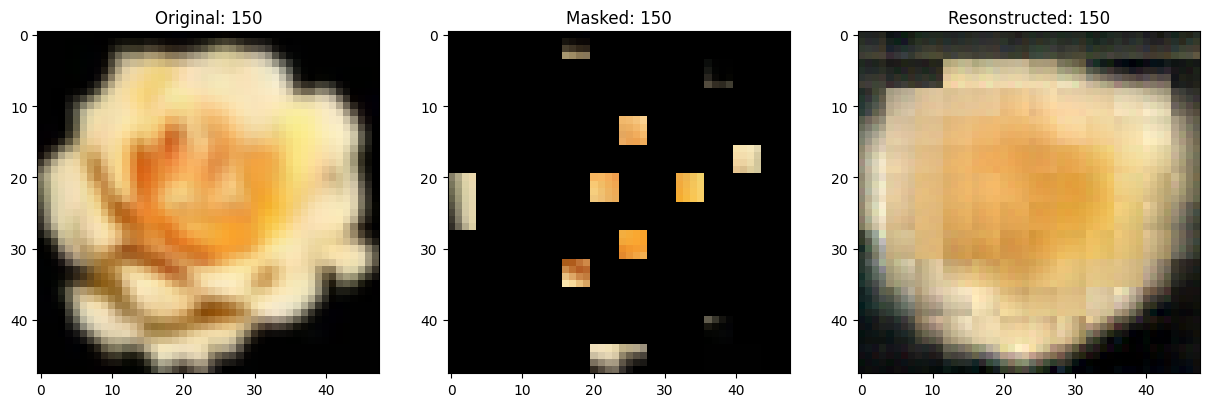

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0901 - loss: 0.5794 - val_loss: 0.5838
Epoch 152/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0902 - loss: 0.5794 - val_loss: 0.5861
Epoch 153/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0899 - loss: 0.5797 - val_loss: 0.5873
Epoch 154/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0898 - loss: 0.5797 - val_loss: 0.5869
Epoch 155/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0898 - loss: 0.5786 - val_loss: 0.5865
Epoch 156/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0899 - loss: 0.5793
Idx chosen: 160


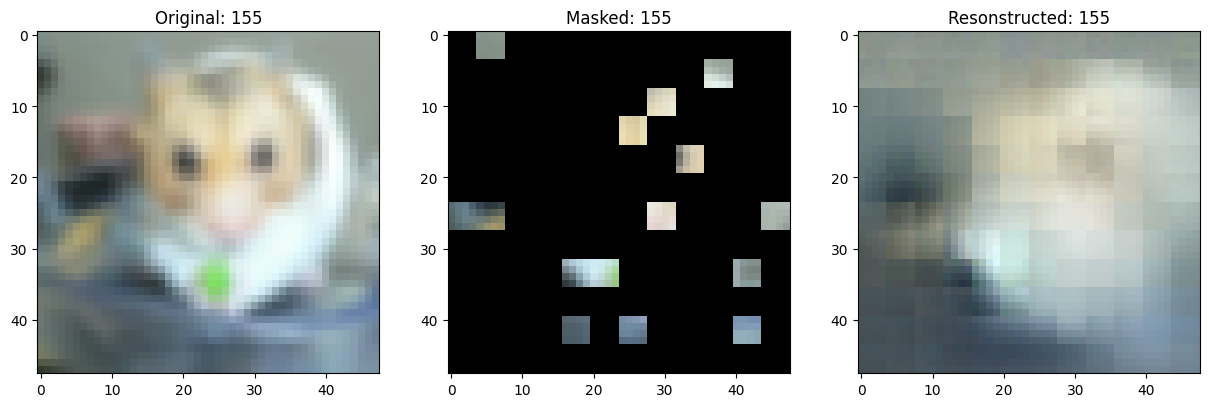

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0899 - loss: 0.5793 - val_loss: 0.5874
Epoch 157/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0898 - loss: 0.5792 - val_loss: 0.5894
Epoch 158/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0896 - loss: 0.5800 - val_loss: 0.5862
Epoch 159/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0895 - loss: 0.5801 - val_loss: 0.5872
Epoch 160/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0897 - loss: 0.5796 - val_loss: 0.5877
Epoch 161/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0895 - loss: 0.5794
Idx chosen: 203


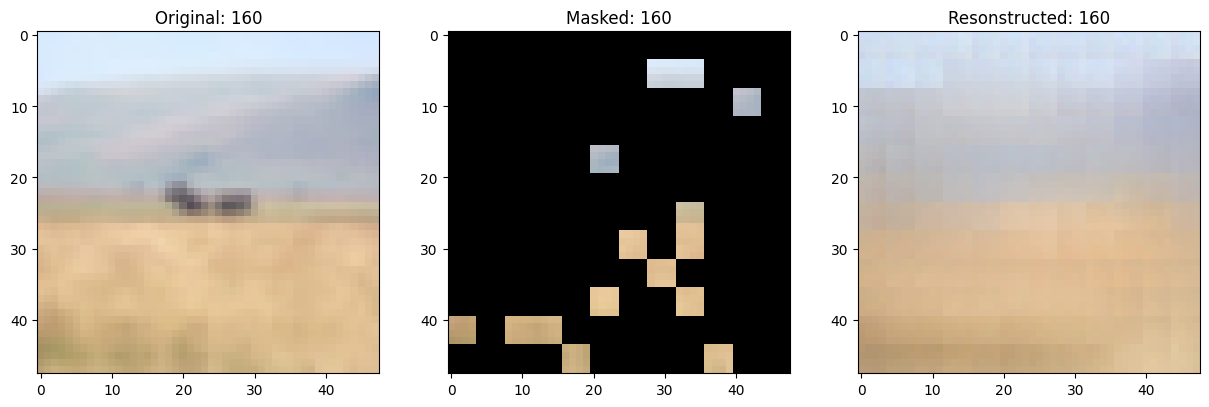

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - mae: 0.0895 - loss: 0.5794 - val_loss: 0.5853
Epoch 162/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0894 - loss: 0.5799 - val_loss: 0.5868
Epoch 163/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0894 - loss: 0.5793 - val_loss: 0.5869
Epoch 164/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0895 - loss: 0.5796 - val_loss: 0.5865
Epoch 165/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0893 - loss: 0.5798 - val_loss: 0.5864
Epoch 166/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0893 - loss: 0.5794
Idx chosen: 57


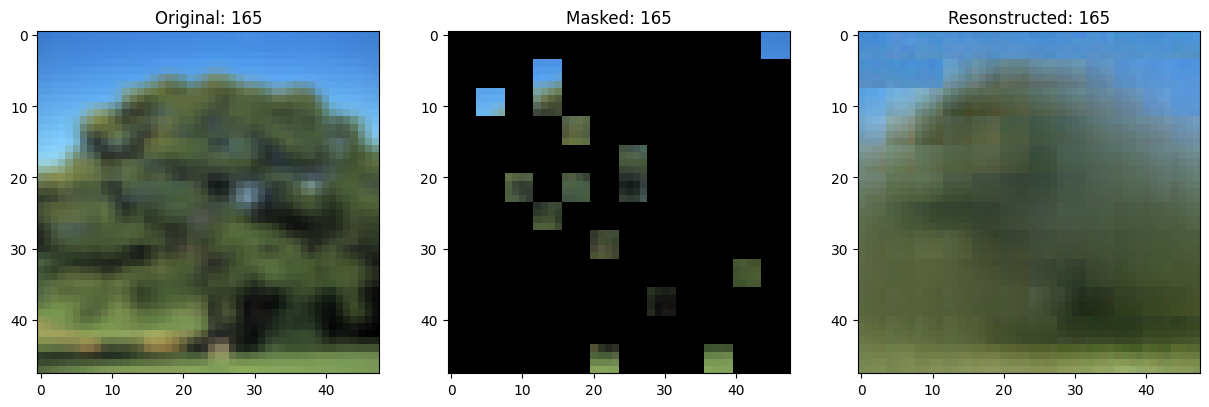

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0893 - loss: 0.5794 - val_loss: 0.5871
Epoch 167/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0892 - loss: 0.5801 - val_loss: 0.5856
Epoch 168/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0892 - loss: 0.5797 - val_loss: 0.5883
Epoch 169/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0890 - loss: 0.5800 - val_loss: 0.5872
Epoch 170/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 385ms/step - mae: 0.0890 - loss: 0.5794 - val_loss: 0.5870
Epoch 171/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0889 - loss: 0.5798


Idx chosen: 21


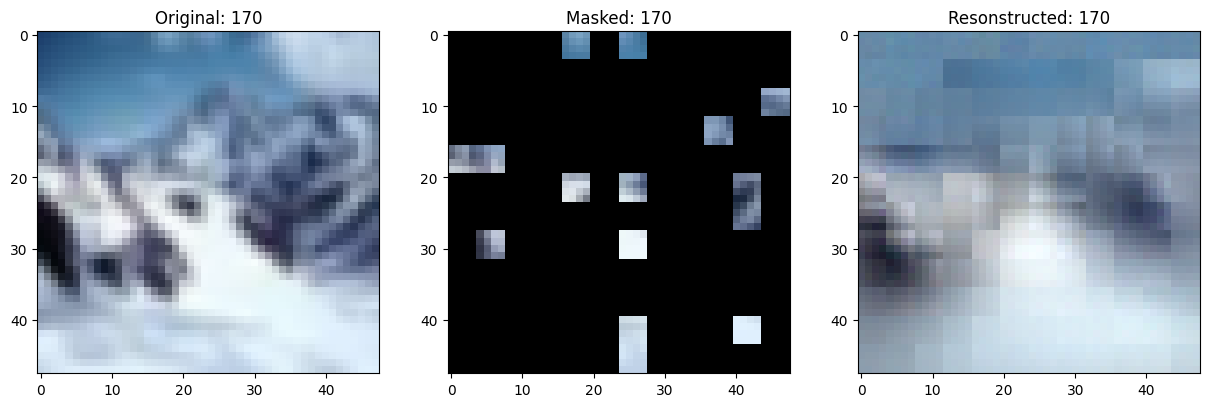

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0889 - loss: 0.5798 - val_loss: 0.5880
Epoch 172/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - mae: 0.0890 - loss: 0.5800 - val_loss: 0.5851
Epoch 173/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0890 - loss: 0.5794 - val_loss: 0.5875
Epoch 174/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0890 - loss: 0.5796 - val_loss: 0.5853
Epoch 175/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0888 - loss: 0.5799 - val_loss: 0.5871
Epoch 176/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0887 - loss: 0.5798
Idx chosen: 252


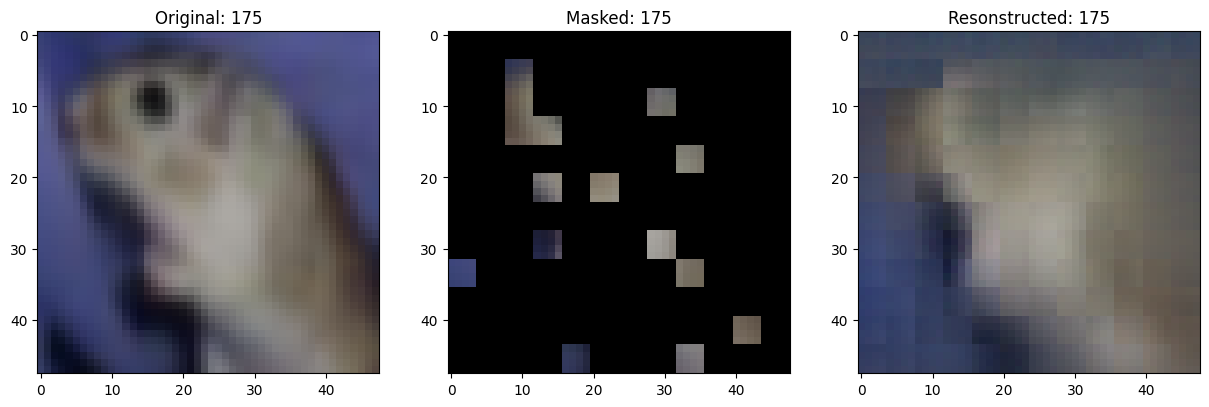

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - mae: 0.0887 - loss: 0.5798 - val_loss: 0.5886
Epoch 177/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0886 - loss: 0.5801 - val_loss: 0.5889
Epoch 178/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0887 - loss: 0.5799 - val_loss: 0.5879
Epoch 179/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0886 - loss: 0.5803 - val_loss: 0.5886
Epoch 180/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0885 - loss: 0.5802 - val_loss: 0.5877
Epoch 181/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0885 - loss: 0.5795


Idx chosen: 235


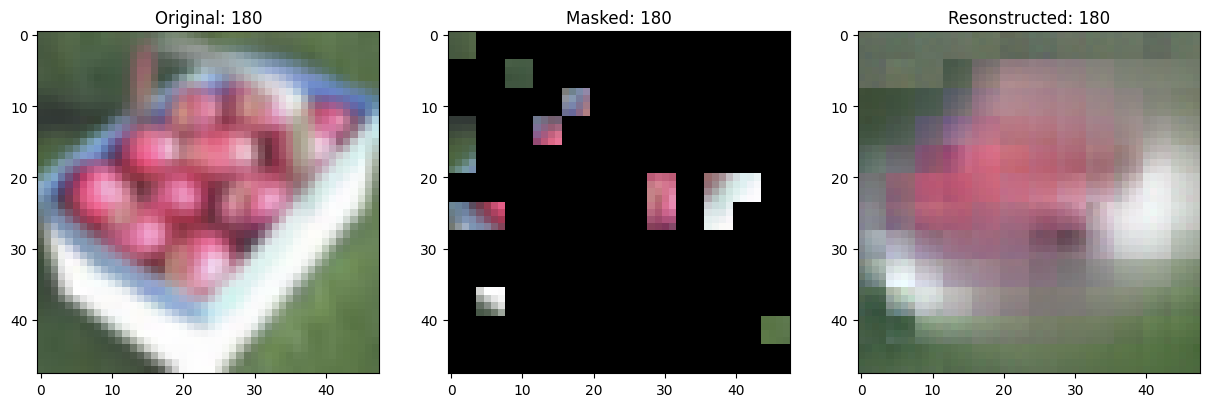

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0885 - loss: 0.5795 - val_loss: 0.5895
Epoch 182/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0883 - loss: 0.5810 - val_loss: 0.5895
Epoch 183/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0887 - loss: 0.5795 - val_loss: 0.5898
Epoch 184/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0883 - loss: 0.5803 - val_loss: 0.5877
Epoch 185/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0882 - loss: 0.5808 - val_loss: 0.5874
Epoch 186/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0881 - loss: 0.5799
Idx chosen: 88


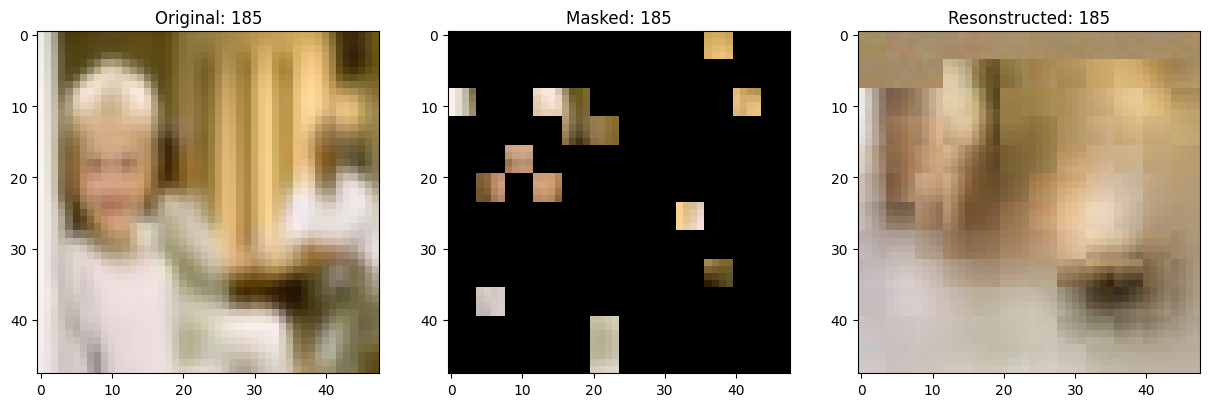

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0881 - loss: 0.5799 - val_loss: 0.5875
Epoch 187/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0883 - loss: 0.5803 - val_loss: 0.5890
Epoch 188/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0884 - loss: 0.5798 - val_loss: 0.5872
Epoch 189/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0881 - loss: 0.5800 - val_loss: 0.5868
Epoch 190/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0882 - loss: 0.5801 - val_loss: 0.5861
Epoch 191/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0882 - loss: 0.5800


Idx chosen: 48


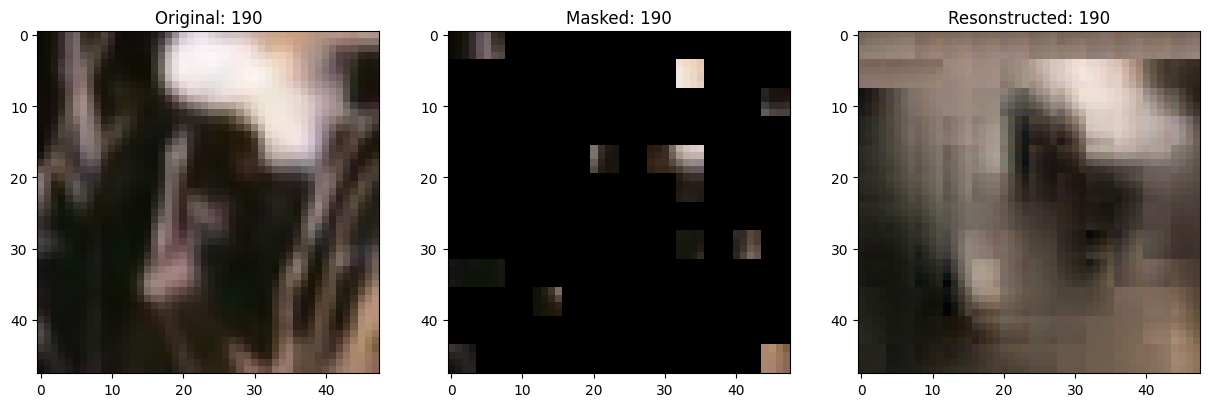

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0882 - loss: 0.5800 - val_loss: 0.5881
Epoch 192/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0878 - loss: 0.5805 - val_loss: 0.5888
Epoch 193/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0880 - loss: 0.5802 - val_loss: 0.5882
Epoch 194/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0879 - loss: 0.5810 - val_loss: 0.5892
Epoch 195/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0881 - loss: 0.5802 - val_loss: 0.5893
Epoch 196/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0879 - loss: 0.5801


Idx chosen: 218


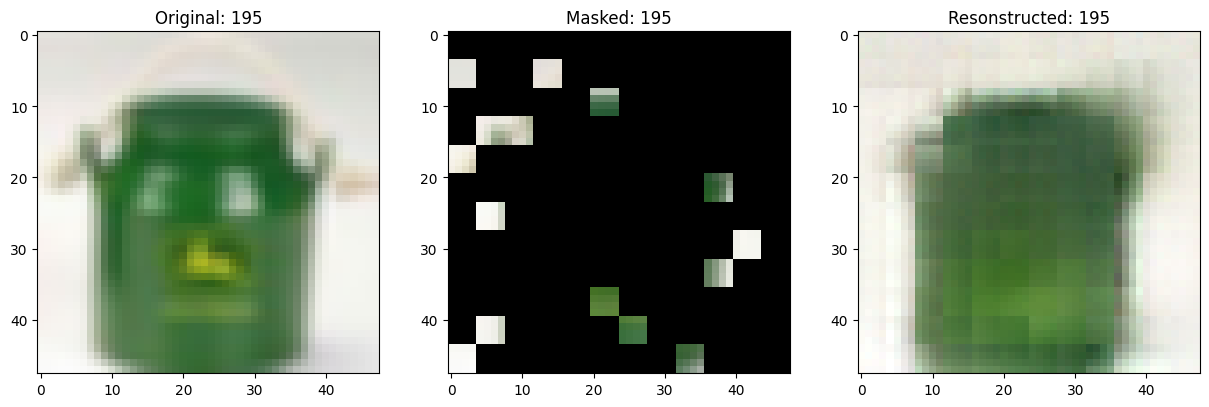

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0879 - loss: 0.5801 - val_loss: 0.5870
Epoch 197/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0878 - loss: 0.5800 - val_loss: 0.5862
Epoch 198/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0877 - loss: 0.5805 - val_loss: 0.5884
Epoch 199/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0878 - loss: 0.5803 - val_loss: 0.5887
Epoch 200/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0878 - loss: 0.5804 - val_loss: 0.5875
Epoch 201/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0876 - loss: 0.5800
Idx chosen: 58


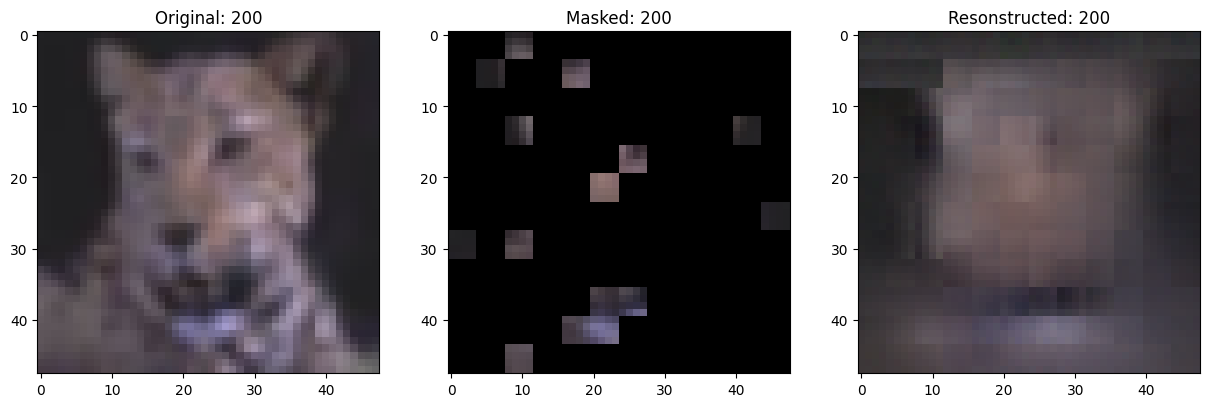

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - mae: 0.0877 - loss: 0.5800 - val_loss: 0.5879
Epoch 202/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0877 - loss: 0.5804 - val_loss: 0.5863
Epoch 203/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0877 - loss: 0.5805 - val_loss: 0.5906
Epoch 204/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0876 - loss: 0.5805 - val_loss: 0.5880
Epoch 205/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0874 - loss: 0.5806 - val_loss: 0.5885
Epoch 206/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0877 - loss: 0.5808
Idx chosen: 254


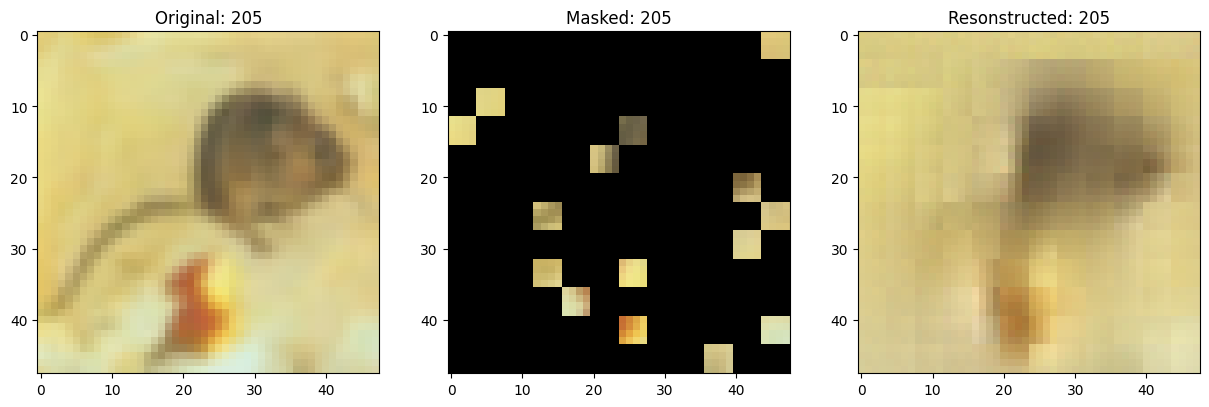

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 390ms/step - mae: 0.0877 - loss: 0.5808 - val_loss: 0.5879
Epoch 207/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0875 - loss: 0.5802 - val_loss: 0.5882
Epoch 208/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0876 - loss: 0.5803 - val_loss: 0.5881
Epoch 209/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0875 - loss: 0.5804 - val_loss: 0.5878
Epoch 210/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0873 - loss: 0.5812 - val_loss: 0.5885
Epoch 211/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0873 - loss: 0.5809


Idx chosen: 169


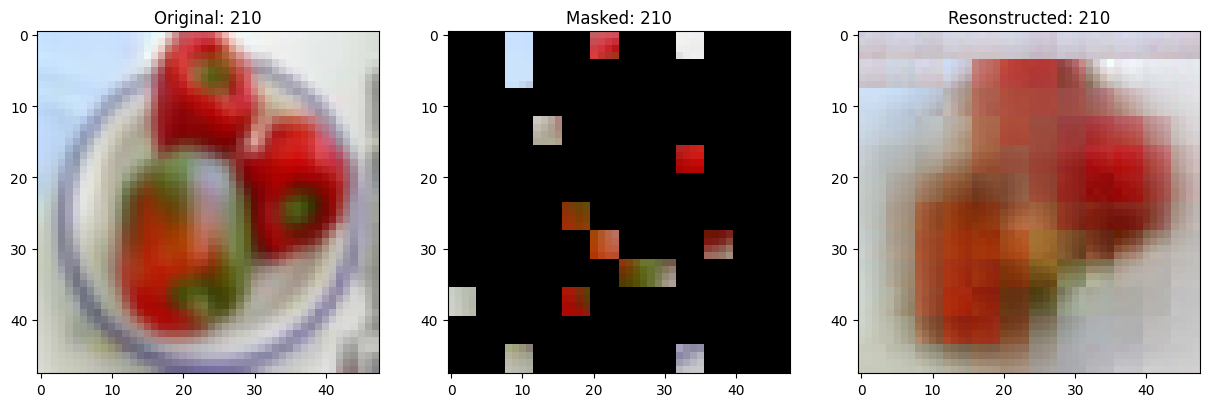

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - mae: 0.0873 - loss: 0.5809 - val_loss: 0.5872
Epoch 212/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0872 - loss: 0.5810 - val_loss: 0.5882
Epoch 213/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0871 - loss: 0.5814 - val_loss: 0.5890
Epoch 214/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0872 - loss: 0.5813 - val_loss: 0.5890
Epoch 215/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - mae: 0.0873 - loss: 0.5805 - val_loss: 0.5879
Epoch 216/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0872 - loss: 0.5807
Idx chosen: 255


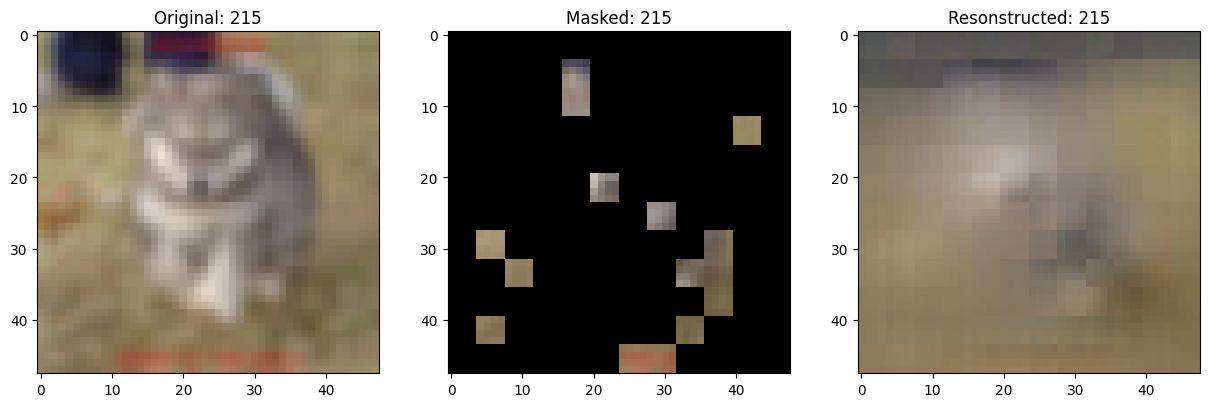

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0872 - loss: 0.5807 - val_loss: 0.5875
Epoch 217/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0872 - loss: 0.5806 - val_loss: 0.5863
Epoch 218/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0872 - loss: 0.5808 - val_loss: 0.5882
Epoch 219/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0873 - loss: 0.5808 - val_loss: 0.5887
Epoch 220/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0872 - loss: 0.5810 - val_loss: 0.5889
Epoch 221/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0870 - loss: 0.5808
Idx chosen: 219


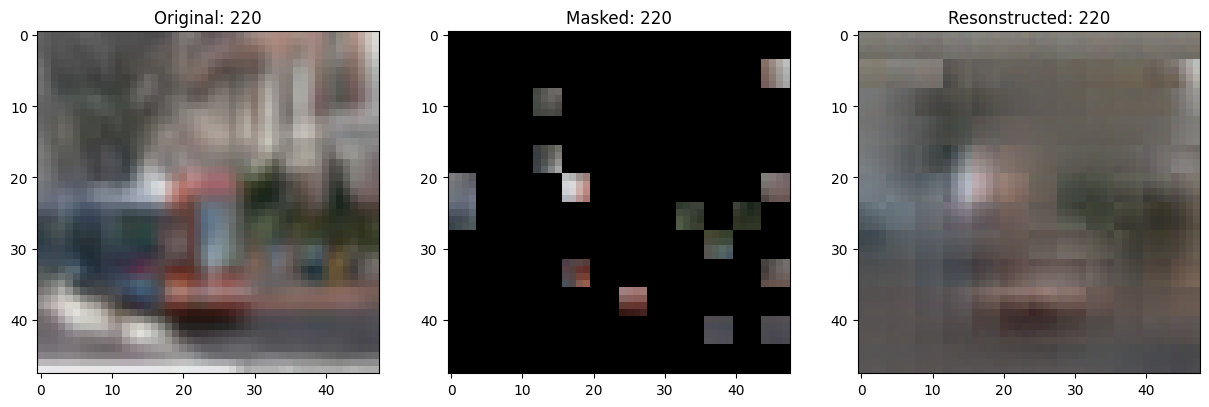

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0870 - loss: 0.5808 - val_loss: 0.5885
Epoch 222/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0870 - loss: 0.5816 - val_loss: 0.5893
Epoch 223/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0870 - loss: 0.5809 - val_loss: 0.5874
Epoch 224/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0872 - loss: 0.5803 - val_loss: 0.5883
Epoch 225/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0871 - loss: 0.5816 - val_loss: 0.5886
Epoch 226/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0870 - loss: 0.5810
Idx chosen: 187


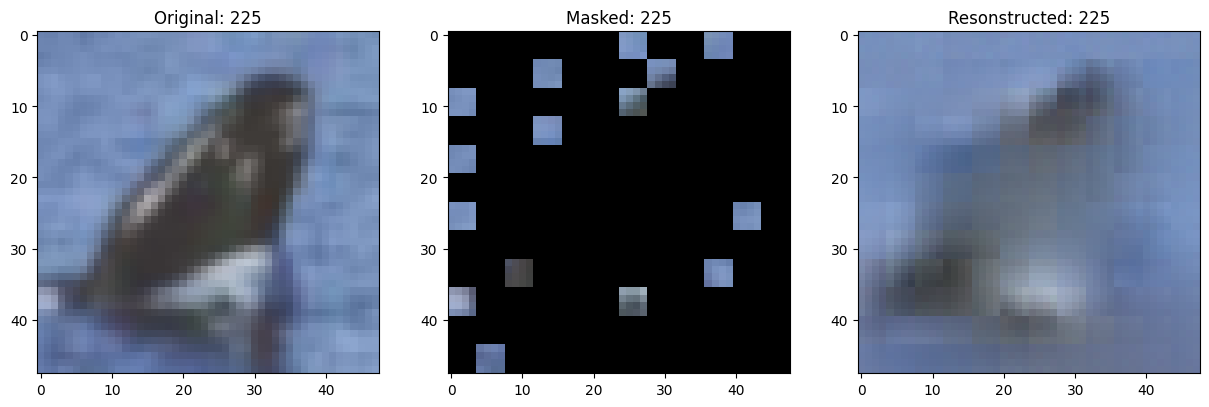

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0870 - loss: 0.5810 - val_loss: 0.5886
Epoch 227/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0870 - loss: 0.5811 - val_loss: 0.5874
Epoch 228/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0871 - loss: 0.5809 - val_loss: 0.5886
Epoch 229/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0870 - loss: 0.5810 - val_loss: 0.5884
Epoch 230/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0871 - loss: 0.5805 - val_loss: 0.5878
Epoch 231/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0869 - loss: 0.5808
Idx chosen: 207


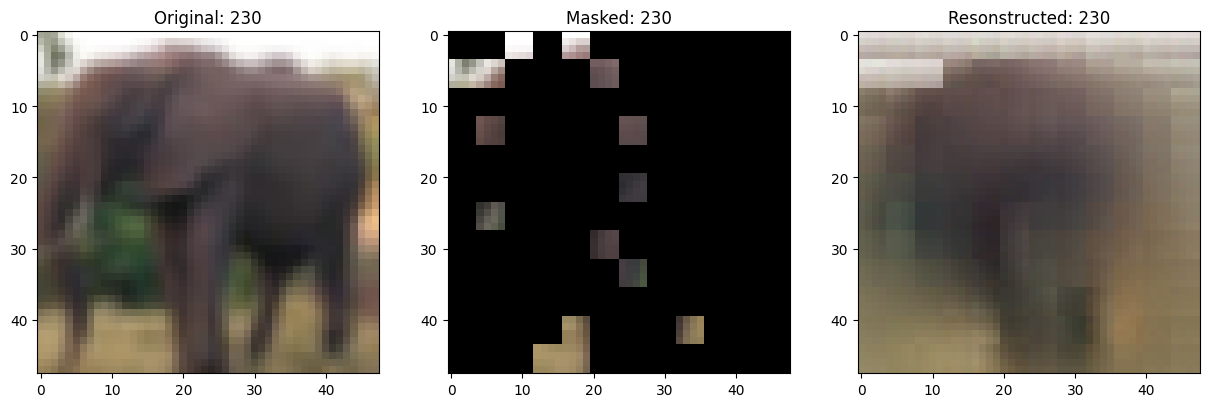

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0869 - loss: 0.5808 - val_loss: 0.5886
Epoch 232/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0873 - loss: 0.5807 - val_loss: 0.5886
Epoch 233/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - mae: 0.0868 - loss: 0.5808 - val_loss: 0.5892
Epoch 234/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0868 - loss: 0.5811 - val_loss: 0.5880
Epoch 235/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0870 - loss: 0.5810 - val_loss: 0.5883
Epoch 236/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - mae: 0.0869 - loss: 0.5808


Idx chosen: 14


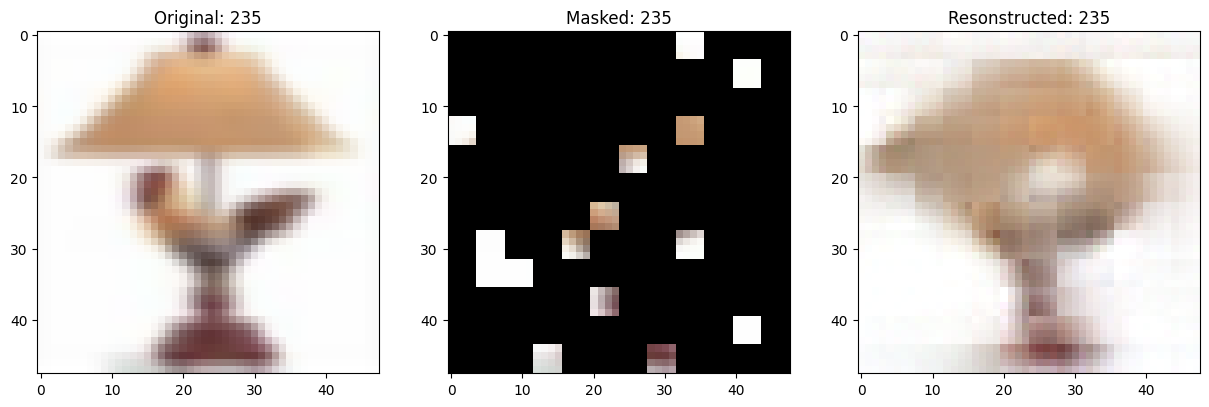

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - mae: 0.0870 - loss: 0.5808 - val_loss: 0.5883
Epoch 237/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 386ms/step - mae: 0.0870 - loss: 0.5810 - val_loss: 0.5882
Epoch 238/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0870 - loss: 0.5810 - val_loss: 0.5878
Epoch 239/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0870 - loss: 0.5810 - val_loss: 0.5886
Epoch 240/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 393ms/step - mae: 0.0870 - loss: 0.5809 - val_loss: 0.5882
Epoch 241/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - mae: 0.0870 - loss: 0.5807
Idx chosen: 189


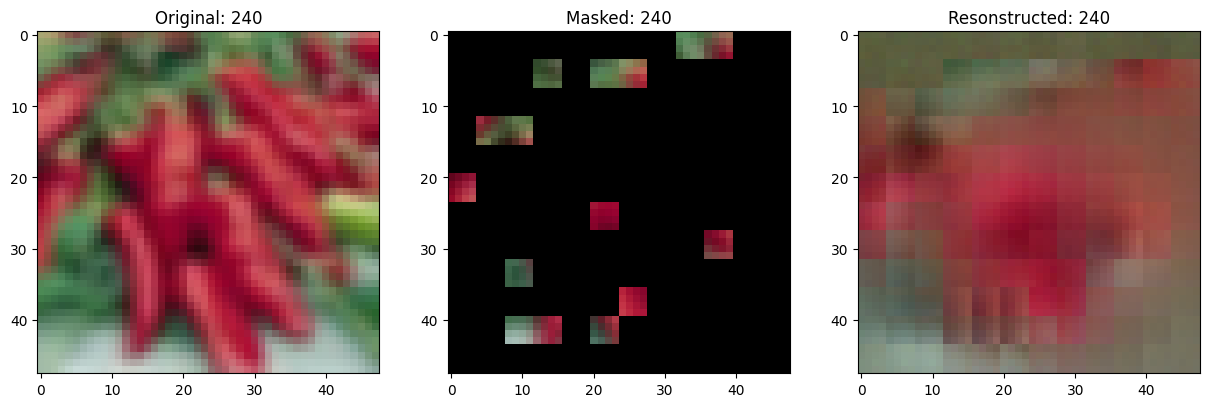

157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0870 - loss: 0.5807 - val_loss: 0.5885
Epoch 242/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0868 - loss: 0.5808 - val_loss: 0.5882
Epoch 243/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0867 - loss: 0.5812 - val_loss: 0.5885
Epoch 244/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0869 - loss: 0.5806 - val_loss: 0.5883
Epoch 245/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0870 - loss: 0.5809 - val_loss: 0.5885
Epoch 246/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - mae: 0.0870 - loss: 0.5803
Idx chosen: 189


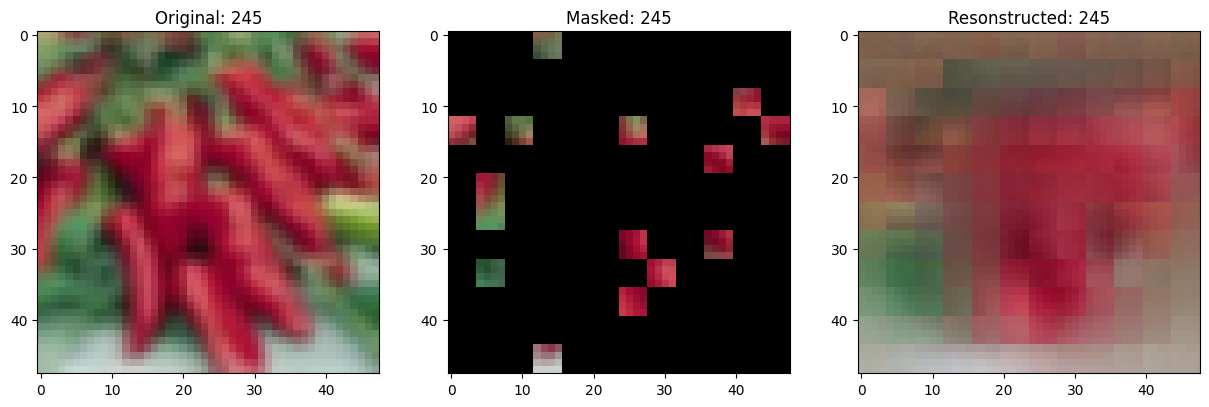

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - mae: 0.0870 - loss: 0.5803 - val_loss: 0.5885
Epoch 247/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0868 - loss: 0.5812 - val_loss: 0.5884
Epoch 248/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0869 - loss: 0.5808 - val_loss: 0.5885
Epoch 249/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - mae: 0.0868 - loss: 0.5806 - val_loss: 0.5886
Epoch 250/250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - mae: 0.0869 - loss: 0.5812 - val_loss: 0.5884
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - mae: 0.0891 - loss: 0.5875
Loss: 0.59


TypeError: unsupported format string passed to dict.__format__

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

# Compile and pretrain the model.
mae_model.compile(
    optimizer=optimizer, loss=keras.losses.MeanSquaredError(), metrics=["mae"]
)
history = mae_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)

# Measure its performance.
loss, mae = mae_model.evaluate(test_ds)
print(f"Loss: {loss:.2f}")
print(f"MAE: {mae:.2f}")